In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/home/al/kp/data-cleaned.csv", sep=",")
df.head()

,WOK,Luas WOK,Total Kecamatan,Total Penduduk,Jumlah Kepala Keluarga,Jumlah Gerai,PDRB,Jumlah CB,Revenue,UMR,Jumlah Karyawan
0,SURABAYA,335.54,31.0,3010364,904222,5,2.203099e+07,344841,732,5288796.00,9
1,BANGKALAN SAMPANG,2488.40,32.0,2012310,522757,2,2.108646e+06,41699,71,2518550.44,2
2,PAMEKASAN SUMENEP,2883.16,40.0,1993162,618674,2,2.777703e+06,33568,59,2542732.79,2
3,SIDOARJO PASURUAN 1,686.15,18.0,2067820,534491,2,1.139342e+07,159467,327,5191541.00,4
4,SIDOARJO PASURUAN 2,1513.41,28.0,1825010,498874,2,9.466564e+06,62276,126,5000624.69,3


In [3]:
df['cb_per_employee'] = df['Jumlah CB'] / df['Jumlah Karyawan']

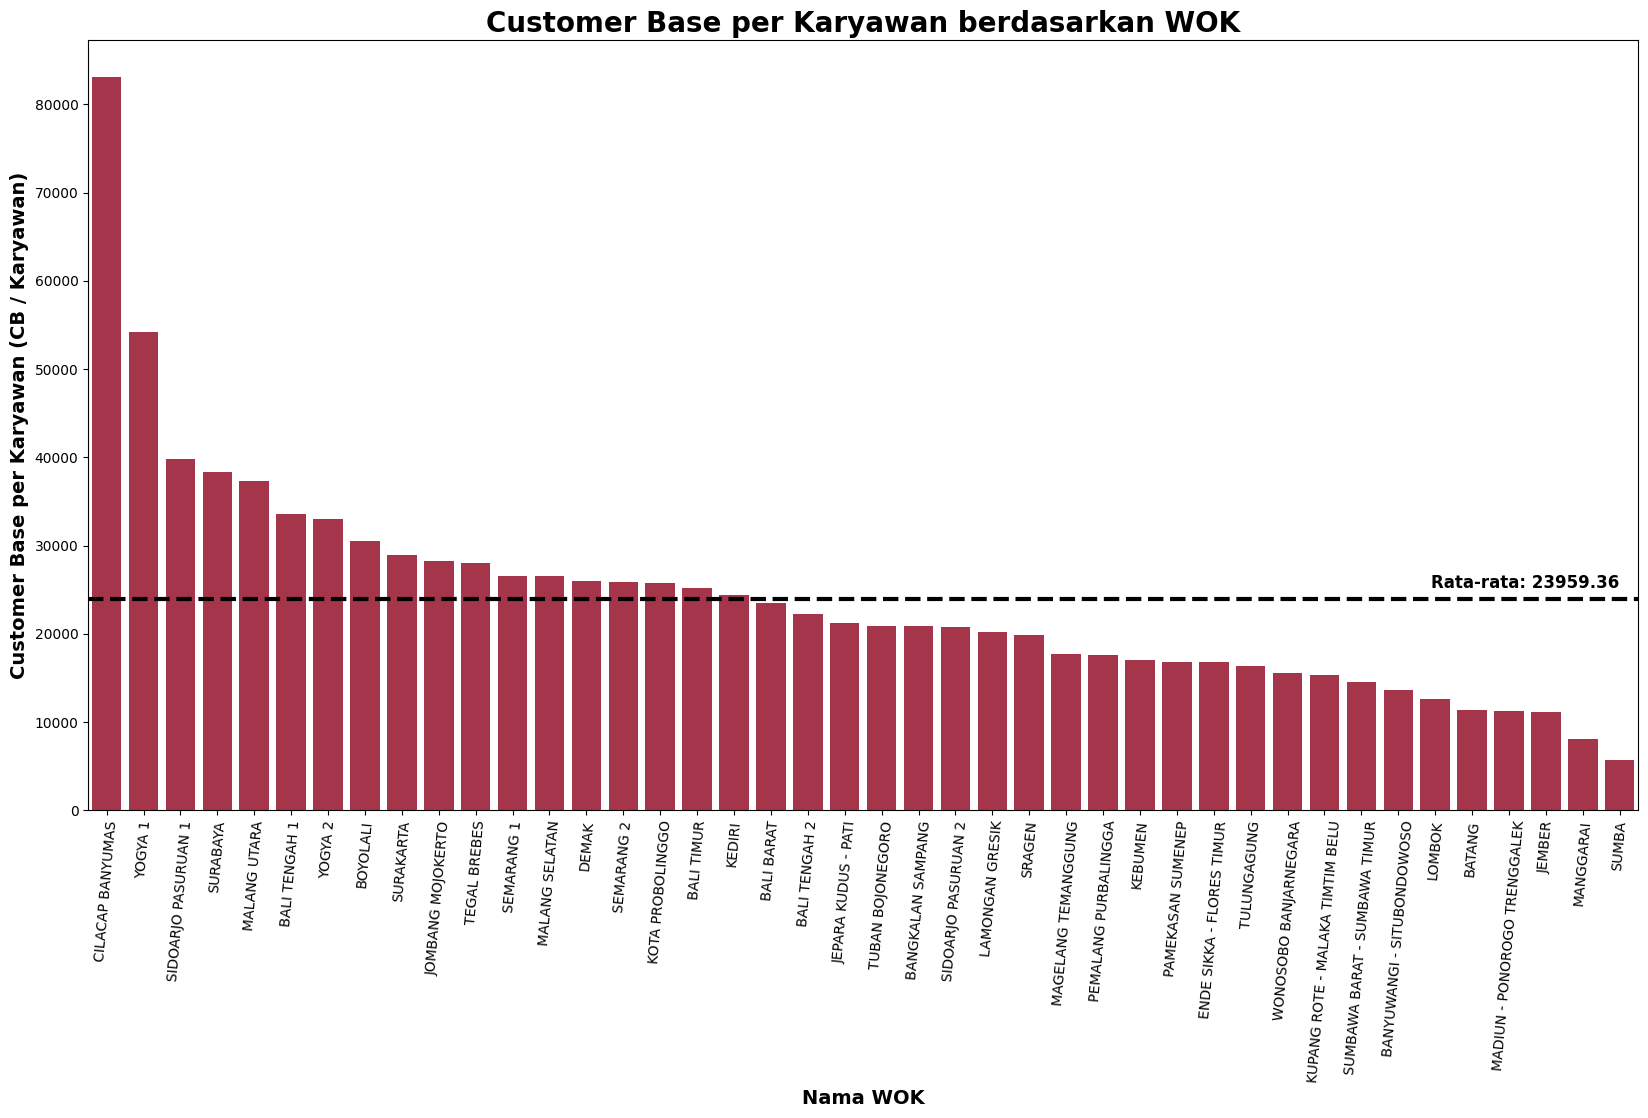

In [7]:
plt.figure(figsize=(20, 10))
sns.barplot(x='WOK', y='cb_per_employee', data=df.sort_values('cb_per_employee', ascending=False), color='#b7223f')
rata_rata = df['cb_per_employee'].mean()
plt.axhline(rata_rata, color='black', linestyle='dashed', linewidth=3)
plt.text(len(df) - 1, rata_rata + 1200, f'Rata-rata: {rata_rata:.2f}', 
         color='black', ha='right', fontweight='bold', fontsize=12)
plt.xticks(rotation=85)

plt.title('Customer Base per Karyawan berdasarkan WOK', fontsize=20, fontweight='bold')
plt.xlabel('Nama WOK', fontsize=14, fontweight='bold')
plt.ylabel('Customer Base per Karyawan (CB / Karyawan)', fontsize=14, fontweight='bold')

plt.savefig('/home/al/kp/assets/cb_per_employee.png', dpi=600, bbox_inches='tight')

Text(0, 0.5, 'Frekuensi')

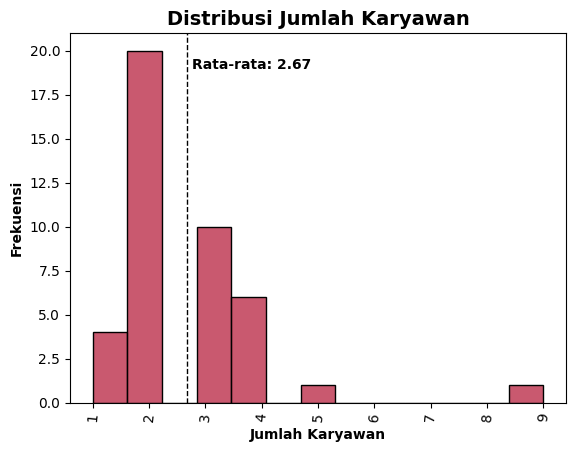

In [48]:
plt.title('Distribusi Jumlah Karyawan', fontsize=14, fontweight='bold')
rata_rata = df['Jumlah Karyawan'].mean()
plt.axvline(rata_rata, color='black', linestyle='dashed', linewidth=1)
plt.text(rata_rata + 0.1, 19, f'Rata-rata: {rata_rata:.2f}', 
         color='black', ha='left', fontweight='bold', fontsize=10)
plt.xticks(rotation=85)

sns.histplot(df, x=df['Jumlah Karyawan'], color='#b7223f')

plt.xlabel('Jumlah Karyawan', fontsize=10, fontweight='bold')
plt.ylabel('Frekuensi', fontsize=10, fontweight='bold')

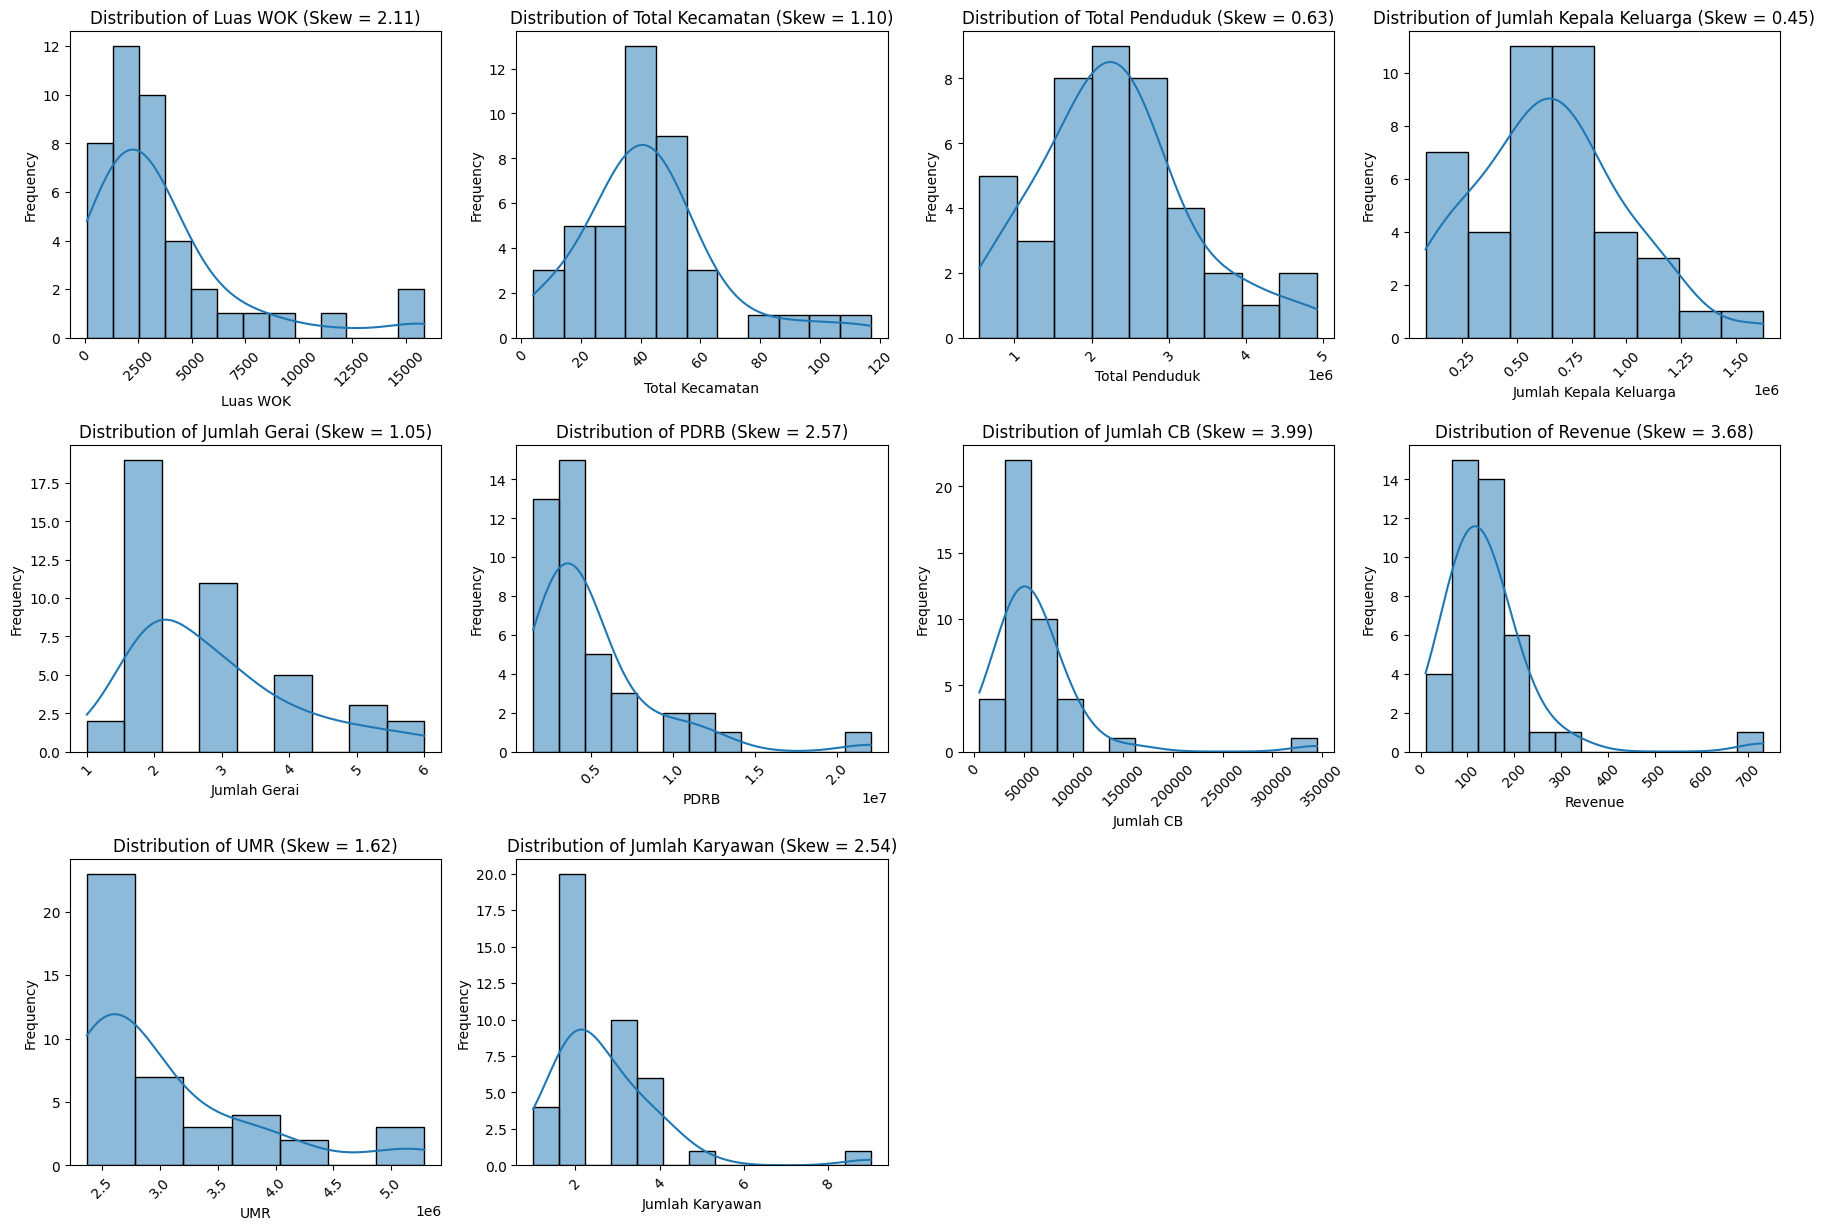

In [3]:
num_cols = list(df.drop(columns=['WOK']).columns)

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
# fig.autofmt_xdate()
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} (Skew = {df[col].skew():.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', labelrotation=45)

# hapus subplot kosong (karena 10 kolom, grid 12)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

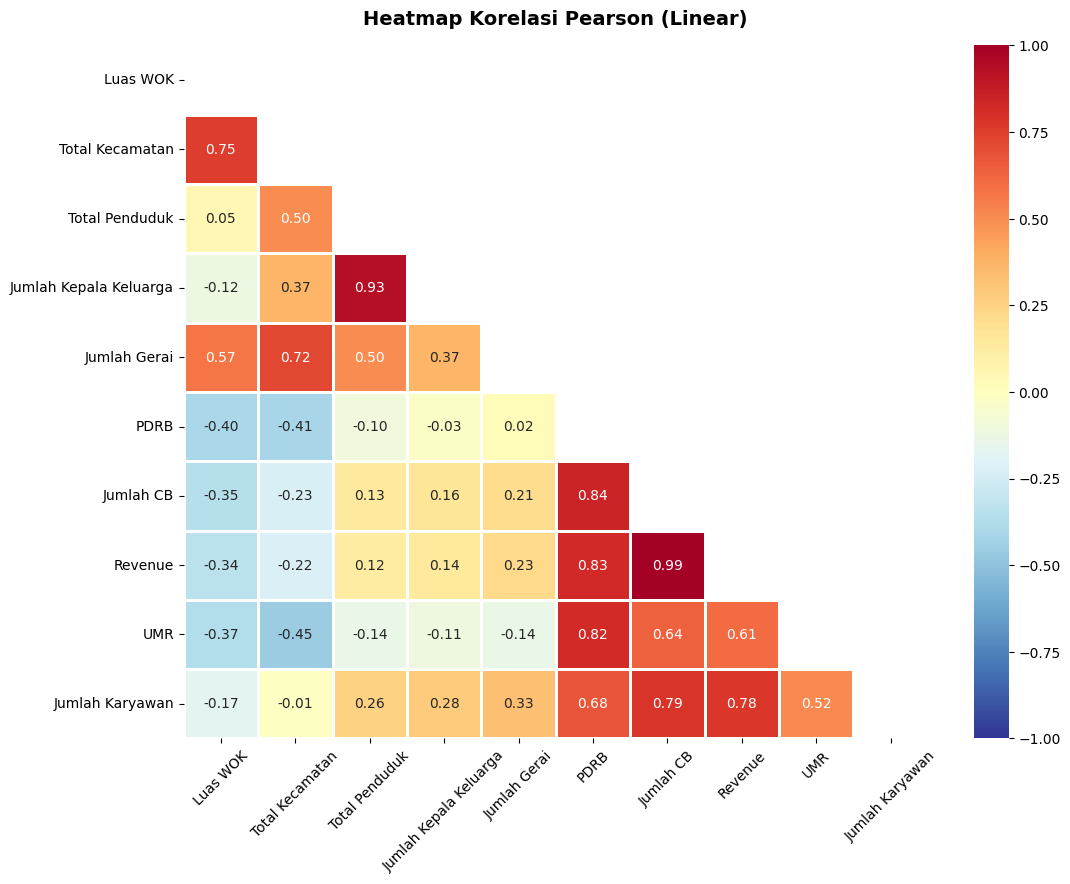

In [5]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns=['WOK']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlBu_r', fmt='.2f', 
            linewidths=1, vmin=-1, vmax=1, center=0)
plt.xticks(rotation=45)
plt.title('Heatmap Korelasi Pearson (Linear)', fontsize=14, fontweight='bold', pad=15)
plt.show()

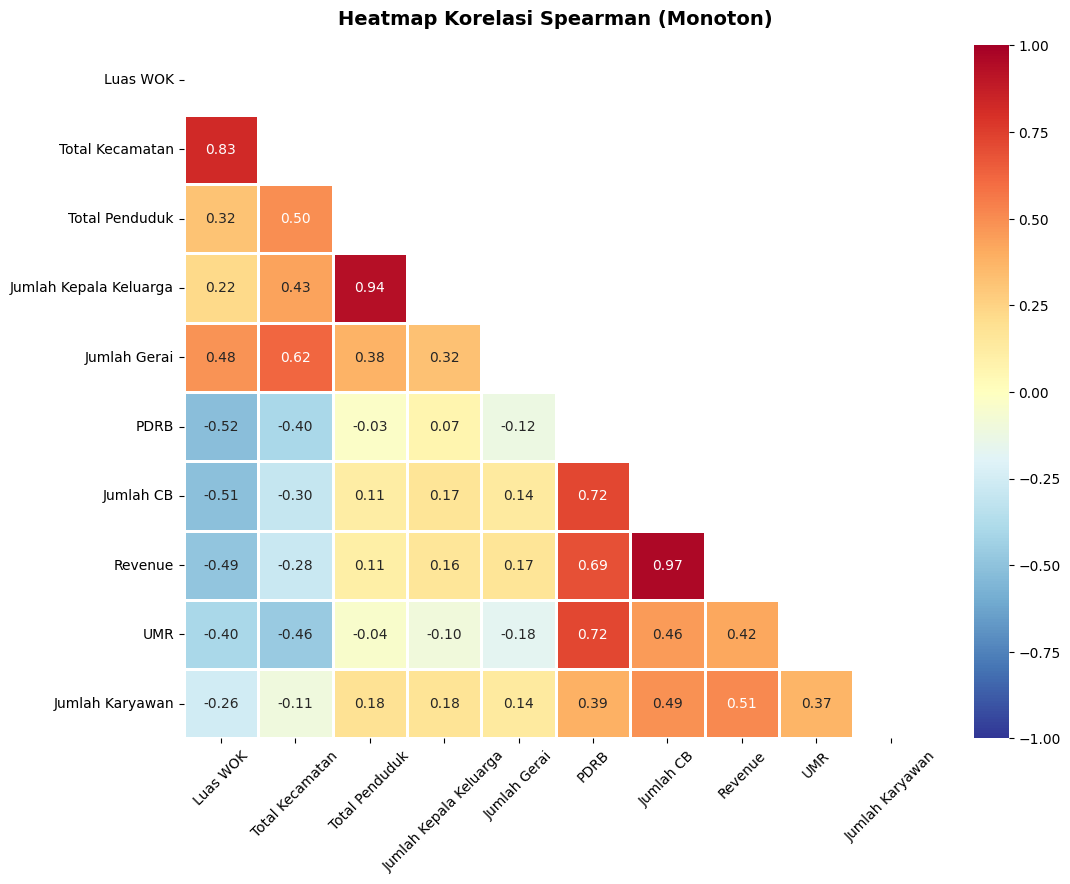

In [6]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns=['WOK']).corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlBu_r', fmt='.2f', 
            linewidths=1, vmin=-1, vmax=1, center=0)
plt.xticks(rotation=45)
plt.title('Heatmap Korelasi Spearman (Monoton)', fontsize=14, fontweight='bold', pad=15)
plt.show()

In [4]:
# df['Gerai Density'] = 1e6 * (df["Jumlah Gerai"] / df["Luas WOK"])
df['Gerai Density'] = (df["Jumlah Gerai"] / df["Luas WOK"])
df['KK Density'] = df["Jumlah Kepala Keluarga"] / df["Luas WOK"]
df['Penduduk Density'] = df["Total Penduduk"] / df["Luas WOK"]
df['revenue_cb'] = np.log(df['Revenue']) * np.log(df['Jumlah CB'])

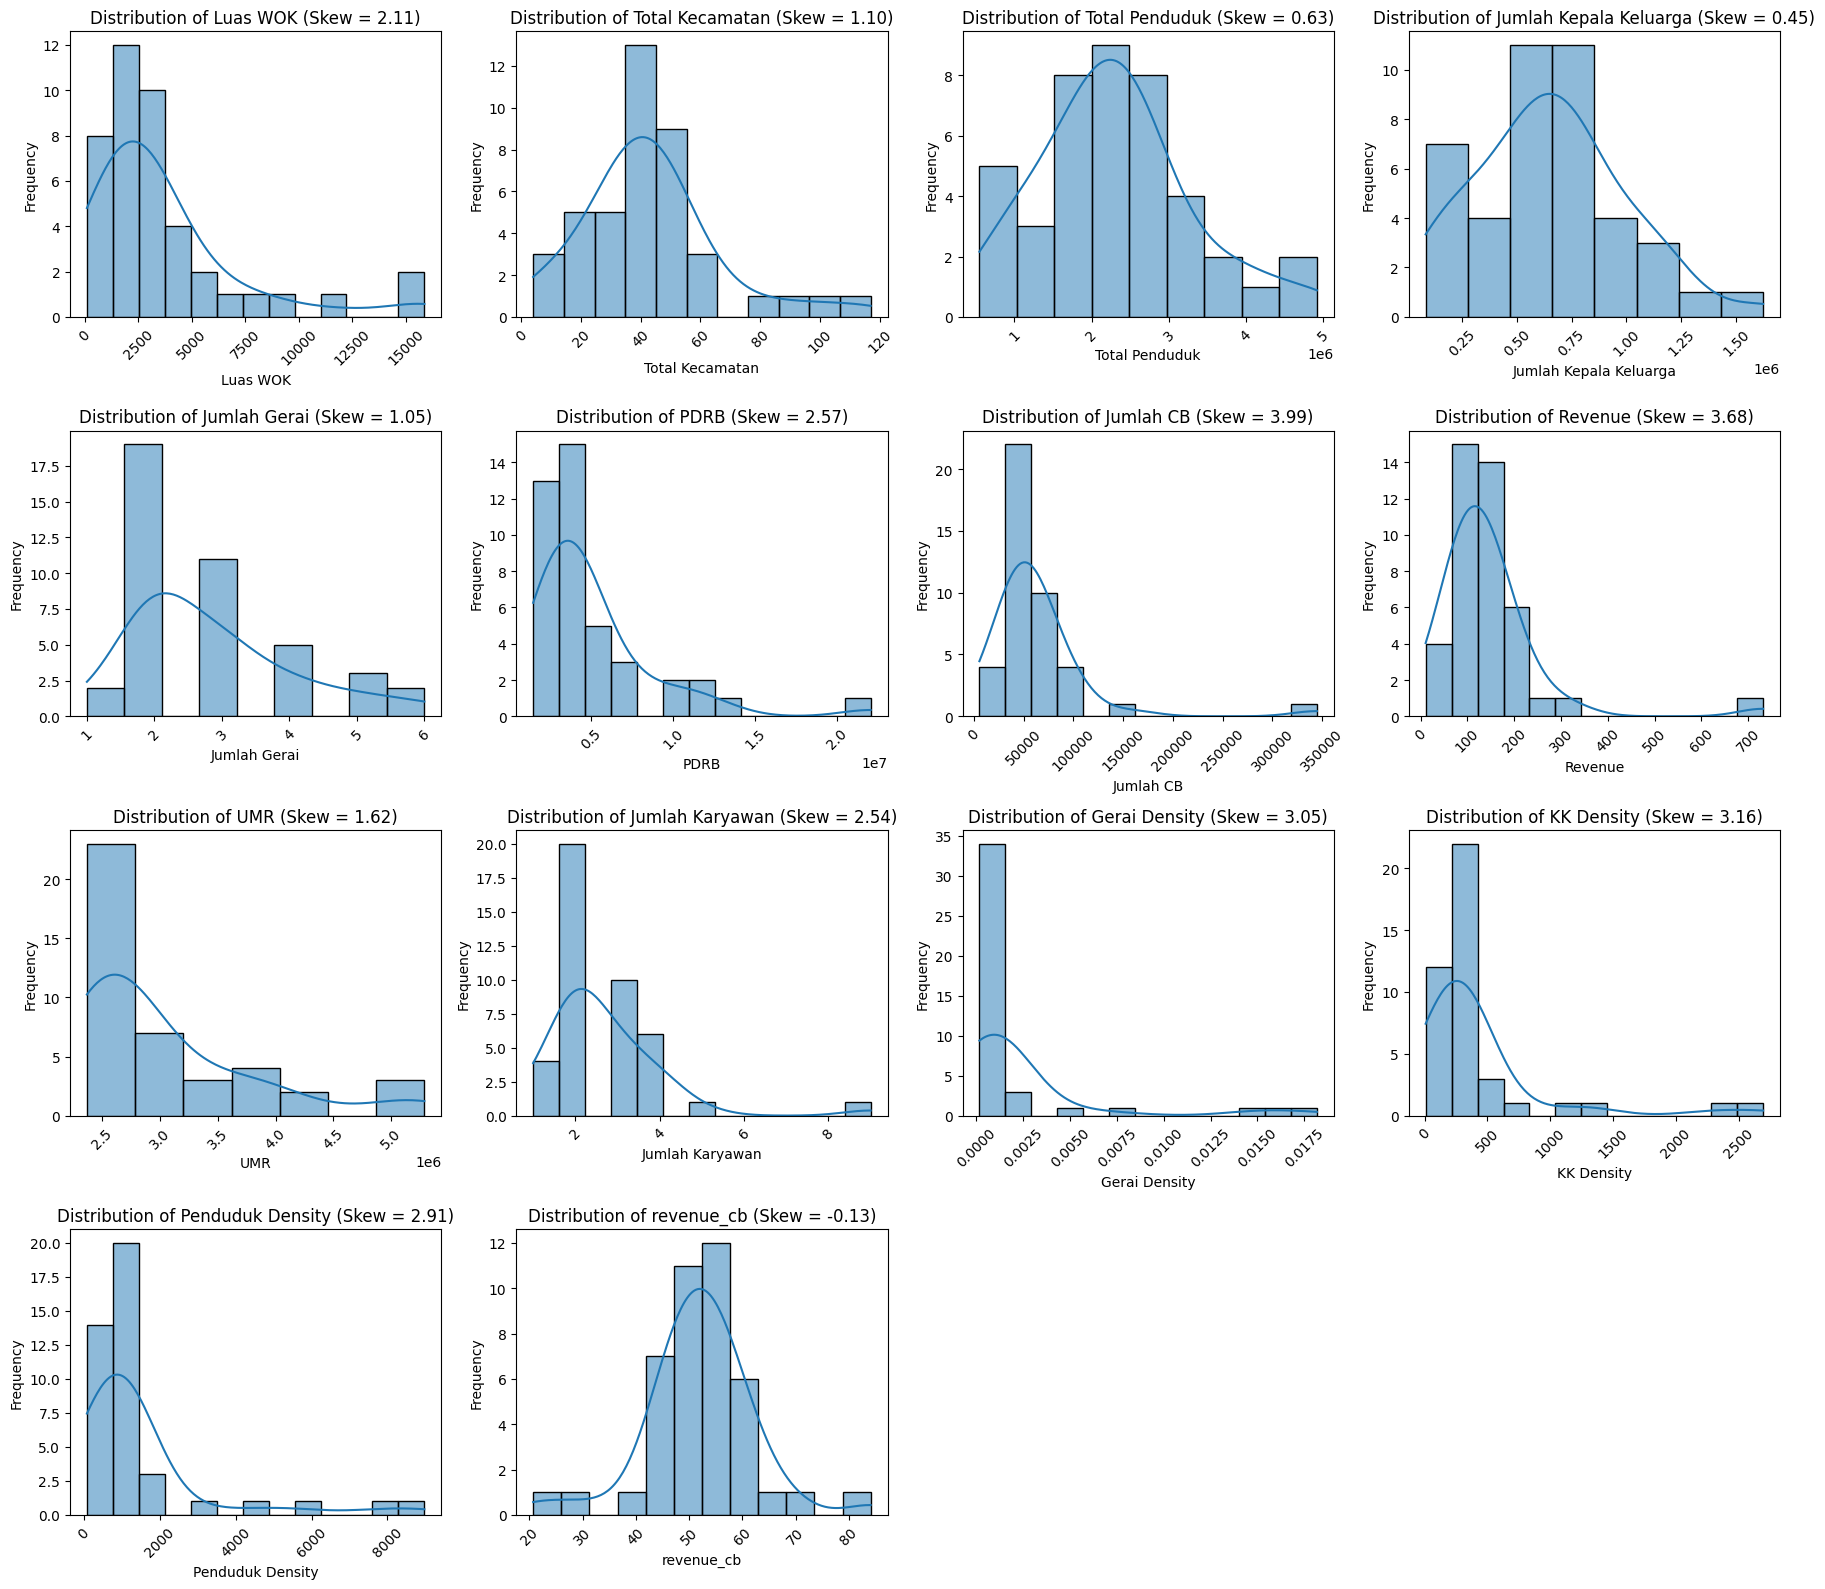

In [8]:
num_cols = list(df.drop(columns=['WOK']).columns)

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
# fig.autofmt_xdate()
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} (Skew = {df[col].skew():.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', labelrotation=45)

# hapus subplot kosong (karena 10 kolom, grid 12)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

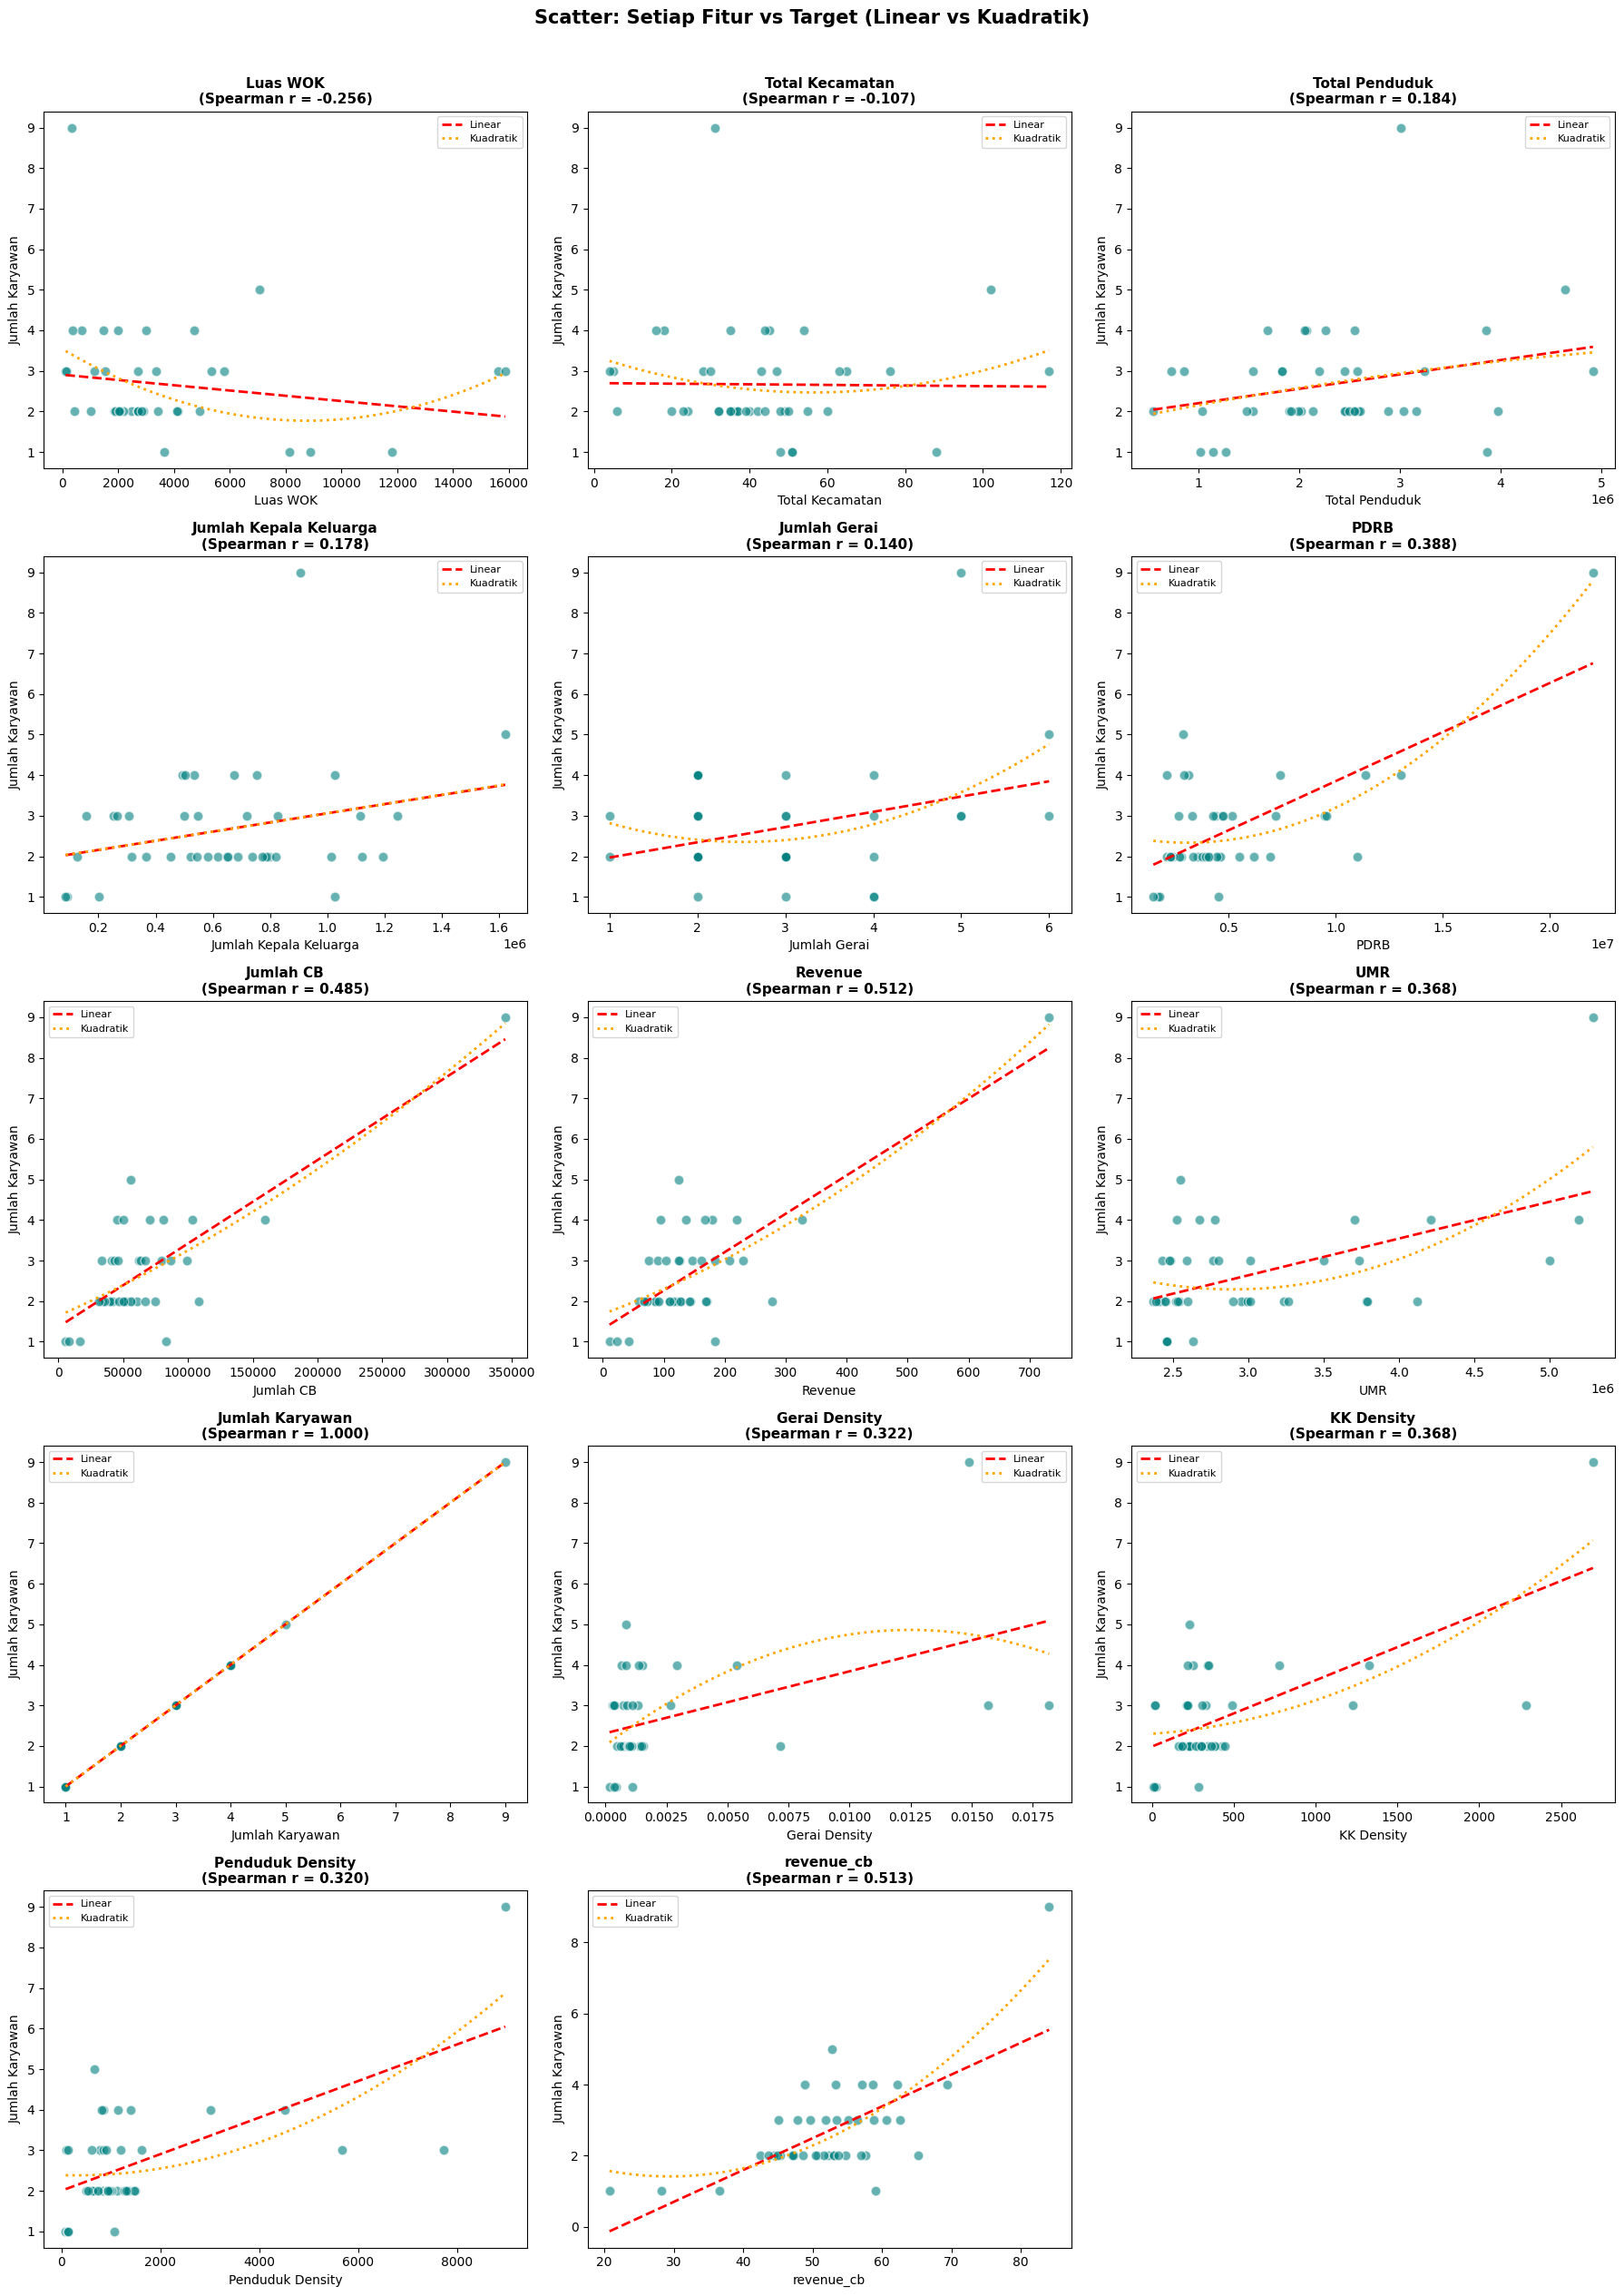

In [9]:
feature_cols = df.drop(columns=['WOK']).columns.tolist()
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

y = df["Jumlah Karyawan"]

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.scatter(df[col], y, alpha=0.6, color='teal', edgecolors='white', s=60)
    
    # Linear trend line
    z = np.polyfit(df[col], y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--', label='Linear')
    
    # Polynomial (quadratic) trend line for comparison
    z2 = np.polyfit(df[col], y, 2)
    p2 = np.poly1d(z2)
    ax.plot(x_line, p2(x_line), color='orange', linewidth=2, linestyle=':', label='Kuadratik')
    
    spearman_r = df[col].corr(y, method='spearman')
    ax.set_title(f'{col}\n(Spearman r = {spearman_r:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah Karyawan')
    ax.legend(fontsize=8)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scatter: Setiap Fitur vs Target (Linear vs Kuadratik)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [5]:
cols1 = ['KK Density', 'Penduduk Density', 'PDRB', 'Jumlah CB', 'Revenue', 'Gerai Density', 'UMR']
# cols2 = ['Gerai Density']

temp_df = df.copy()
for col in cols1:
    # temp_df[col] = 1 / np.sqrt(temp_df[col])
    temp_df[col] = np.log(temp_df[col])

# for col in cols2:
#     temp_df[col] = 1 / np.sqrt(temp_df[col])
#     # temp_df[col] = np.log(temp_df[col])

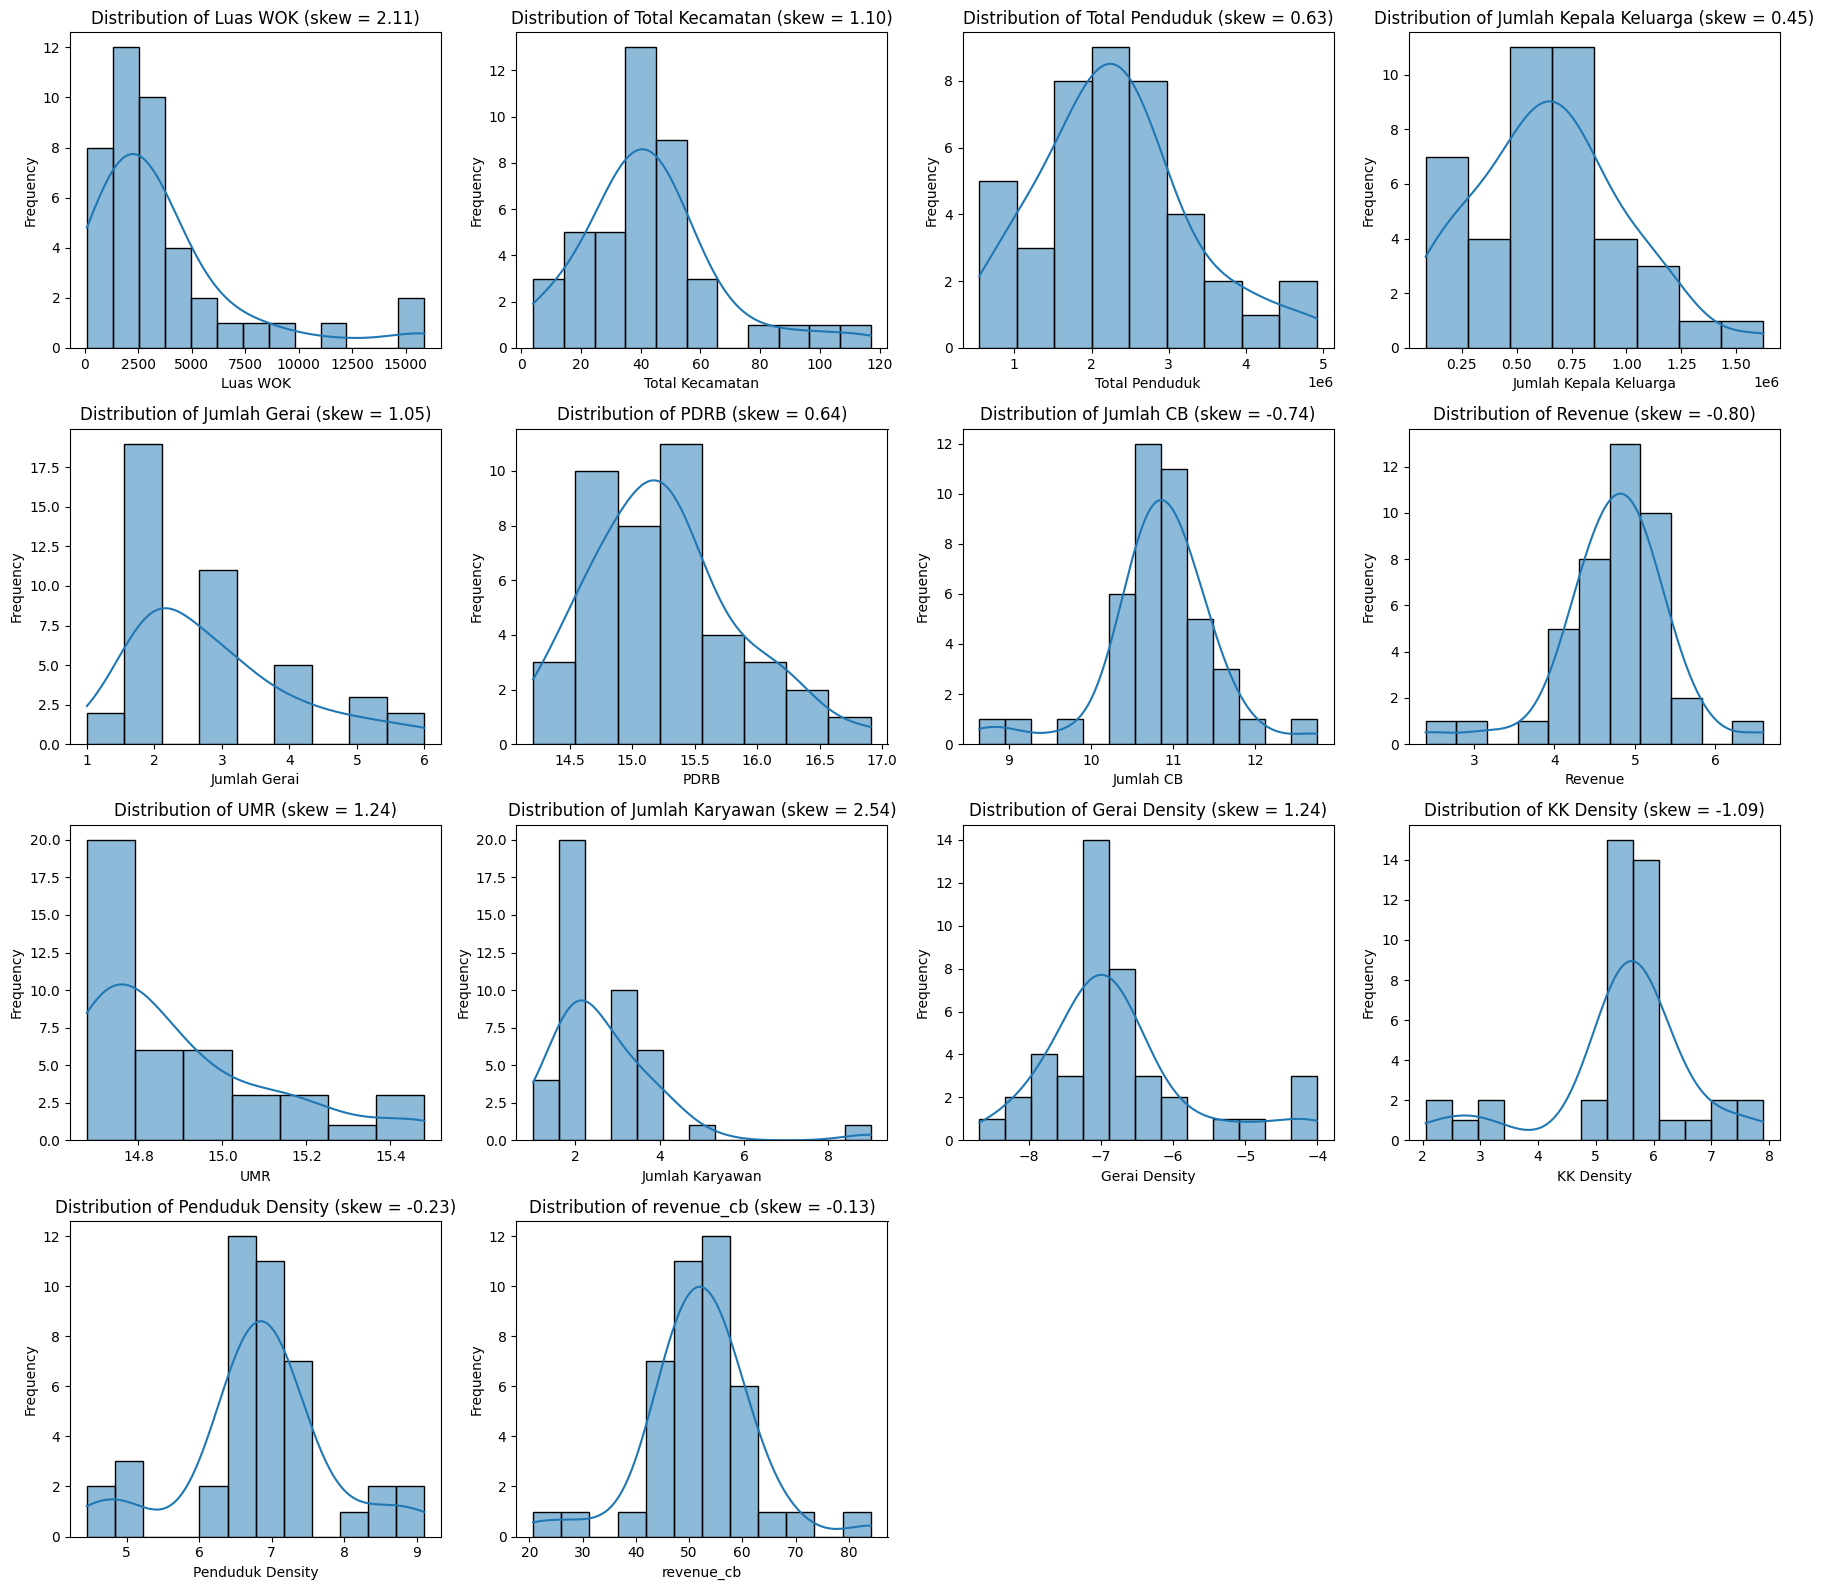

In [11]:
num_cols = list(temp_df.drop(columns=['WOK']).columns)

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(temp_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} (skew = {temp_df[col].skew():.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# hapus subplot kosong (karena 10 kolom, grid 12)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
temp_df = temp_df[[d for d in temp_df.columns if d != 'Jumlah Karyawan'] + ['Jumlah Karyawan']]

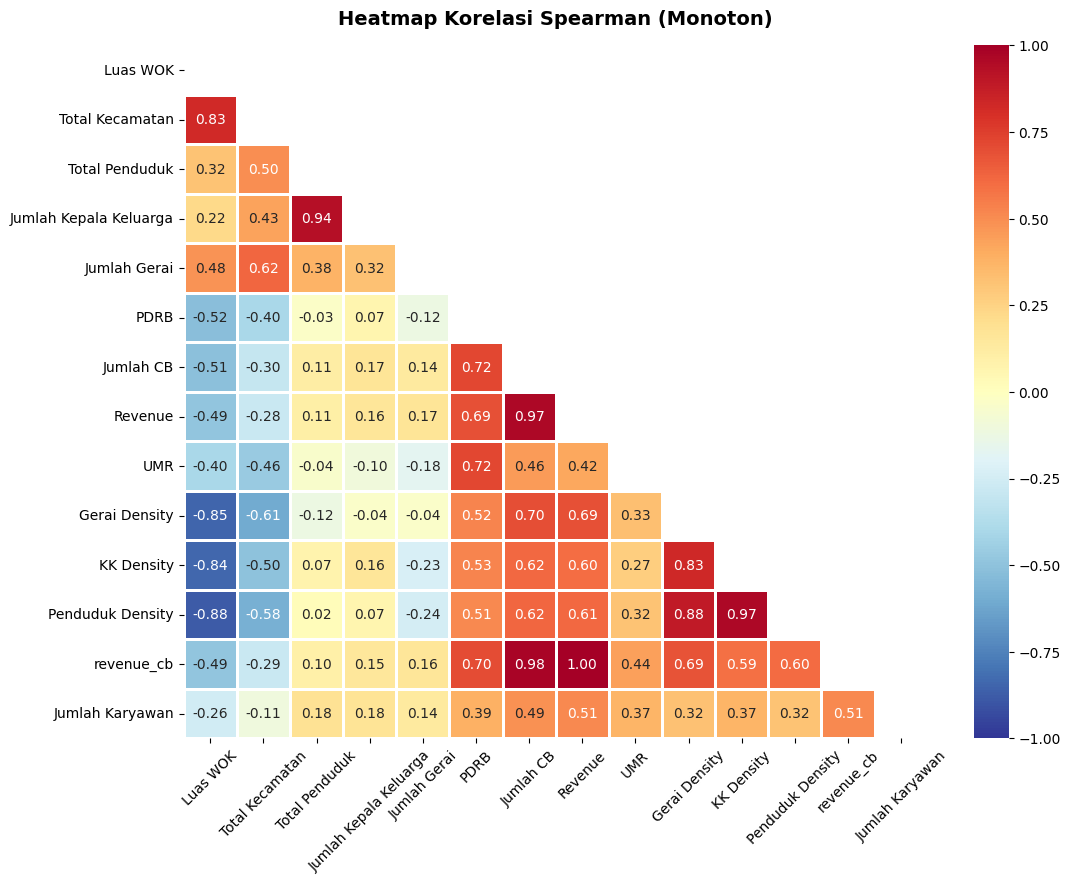

In [9]:
plt.figure(figsize=(12, 9))
corr = temp_df.drop(columns=['WOK']).corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlBu_r', fmt='.2f', 
            linewidths=1, vmin=-1, vmax=1, center=0)
plt.xticks(rotation=45)
plt.title('Heatmap Korelasi Spearman (Monoton)', fontsize=14, fontweight='bold', pad=15)
plt.show()

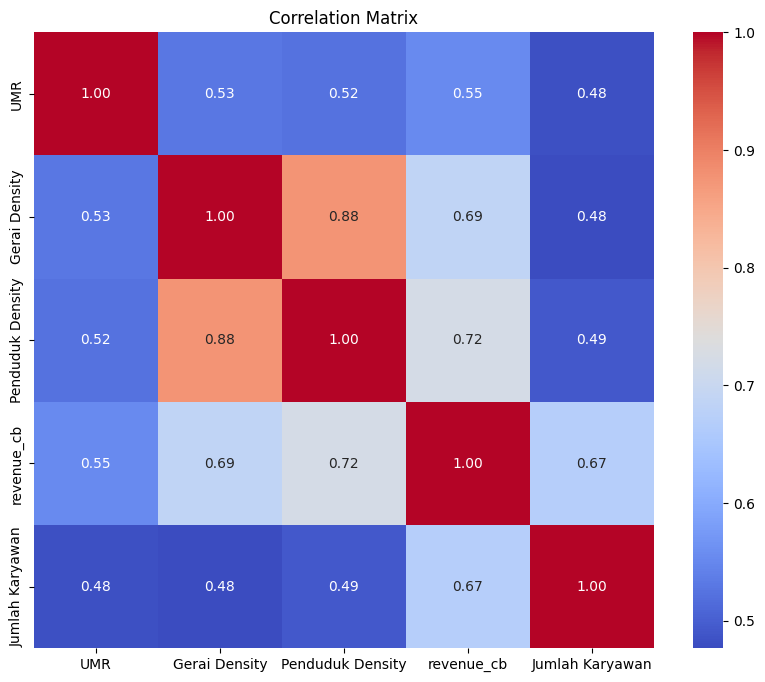

In [14]:
plt.figure(figsize=(10, 8))
corr = temp_df.drop(columns=['WOK', 'Luas WOK', 'Total Kecamatan', 'Total Penduduk', 'Jumlah Kepala Keluarga', 'Jumlah Gerai', 'Jumlah CB', 'Revenue', 'KK Density', 'PDRB']).corr(method='pearson')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['UMR', 'Gerai Density', 'KK Density', 'revenue_cb']
target = 'Jumlah Karyawan'

X = temp_df[features]
y = temp_df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(np.cumsum(pca.explained_variance_ratio_))

[0.72524794 0.14919444 0.07958416 0.04597346]
[0.72524794 0.87444238 0.95402654 1.        ]


In [8]:

from sklearn.model_selection import LeaveOneOut, RepeatedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Models
from sklearn.linear_model import (
    Ridge, 
    Lasso, 
    HuberRegressor, 
    PoissonRegressor, 
    LinearRegression, 
    ElasticNet, 
    Lars, 
    BayesianRidge, 
    TweedieRegressor
)

features = ['UMR', 'Gerai Density', 'KK Density', 'revenue_cb']
target = 'Jumlah Karyawan'

X = temp_df[features]
y = temp_df[target]

models = {
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Huber Regressor": HuberRegressor(),
    "Poisson Regressor": PoissonRegressor(),
    "Tweedie Regressor (power=1.5)": TweedieRegressor(power=1.5),
    "Linear Regressor": LinearRegression(),
    "ElasticNet": ElasticNet(),
    "Lars": Lars(),
    "Bayesian Ridge": BayesianRidge()
}

loo = LeaveOneOut()
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

results = []
predictions_dict = {}

print("=== DUAL-STRATEGY MODEL BENCHMARKING ===\n")

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=3)),
        ('regressor', model)
    ])

    y_pred_raw_loo = cross_val_predict(pipeline, X, y, cv=loo)
    
    y_pred_final_loo = np.maximum(1, y_pred_raw_loo)
    predictions_dict[name] = y_pred_final_loo

    mae_loo = mean_absolute_error(y, y_pred_final_loo)
    rmse_loo = np.sqrt(mean_squared_error(y, y_pred_final_loo))
    r2_loo = r2_score(y, y_pred_final_loo)
    
    scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}
    cv_results = cross_validate(pipeline, X, y, cv=rkf, scoring=scoring)
    
    mae_rkf = -cv_results['test_mae'].mean()
    rmse_rkf = -cv_results['test_rmse'].mean()

    results.append({
        'Model': name,
        'LOO RMSE': round(rmse_loo, 3),
        'RKF RMSE': round(rmse_rkf, 3),
        'RMSE Diff': round(abs(rmse_loo - rmse_rkf), 3),
        'LOO MAE': round(mae_loo, 3),
        'RKF MAE': round(mae_rkf, 3),
        'LOO R2': round(r2_loo, 3)
    })

results_df = pd.DataFrame(results).sort_values(by='LOO RMSE')
print(results_df.to_string(index=False))

=== DUAL-STRATEGY MODEL BENCHMARKING ===

                        Model  LOO RMSE  RKF RMSE  RMSE Diff  LOO MAE  RKF MAE  LOO R2
            Poisson Regressor     1.105     1.062      0.043    0.778    0.797   0.337
              Huber Regressor     1.111     1.073      0.038    0.732    0.778   0.330
Tweedie Regressor (power=1.5)     1.113     1.059      0.054    0.782    0.801   0.327
             Ridge Regression     1.158     1.149      0.009    0.779    0.851   0.272
                         Lars     1.159     1.156      0.003    0.778    0.854   0.271
             Linear Regressor     1.159     1.156      0.003    0.778    0.854   0.271
               Bayesian Ridge     1.181     1.155      0.026    0.793    0.860   0.243
                   ElasticNet     1.282     1.170      0.112    0.881    0.899   0.107
             Lasso Regression     1.342     1.207      0.134    0.920    0.935   0.022


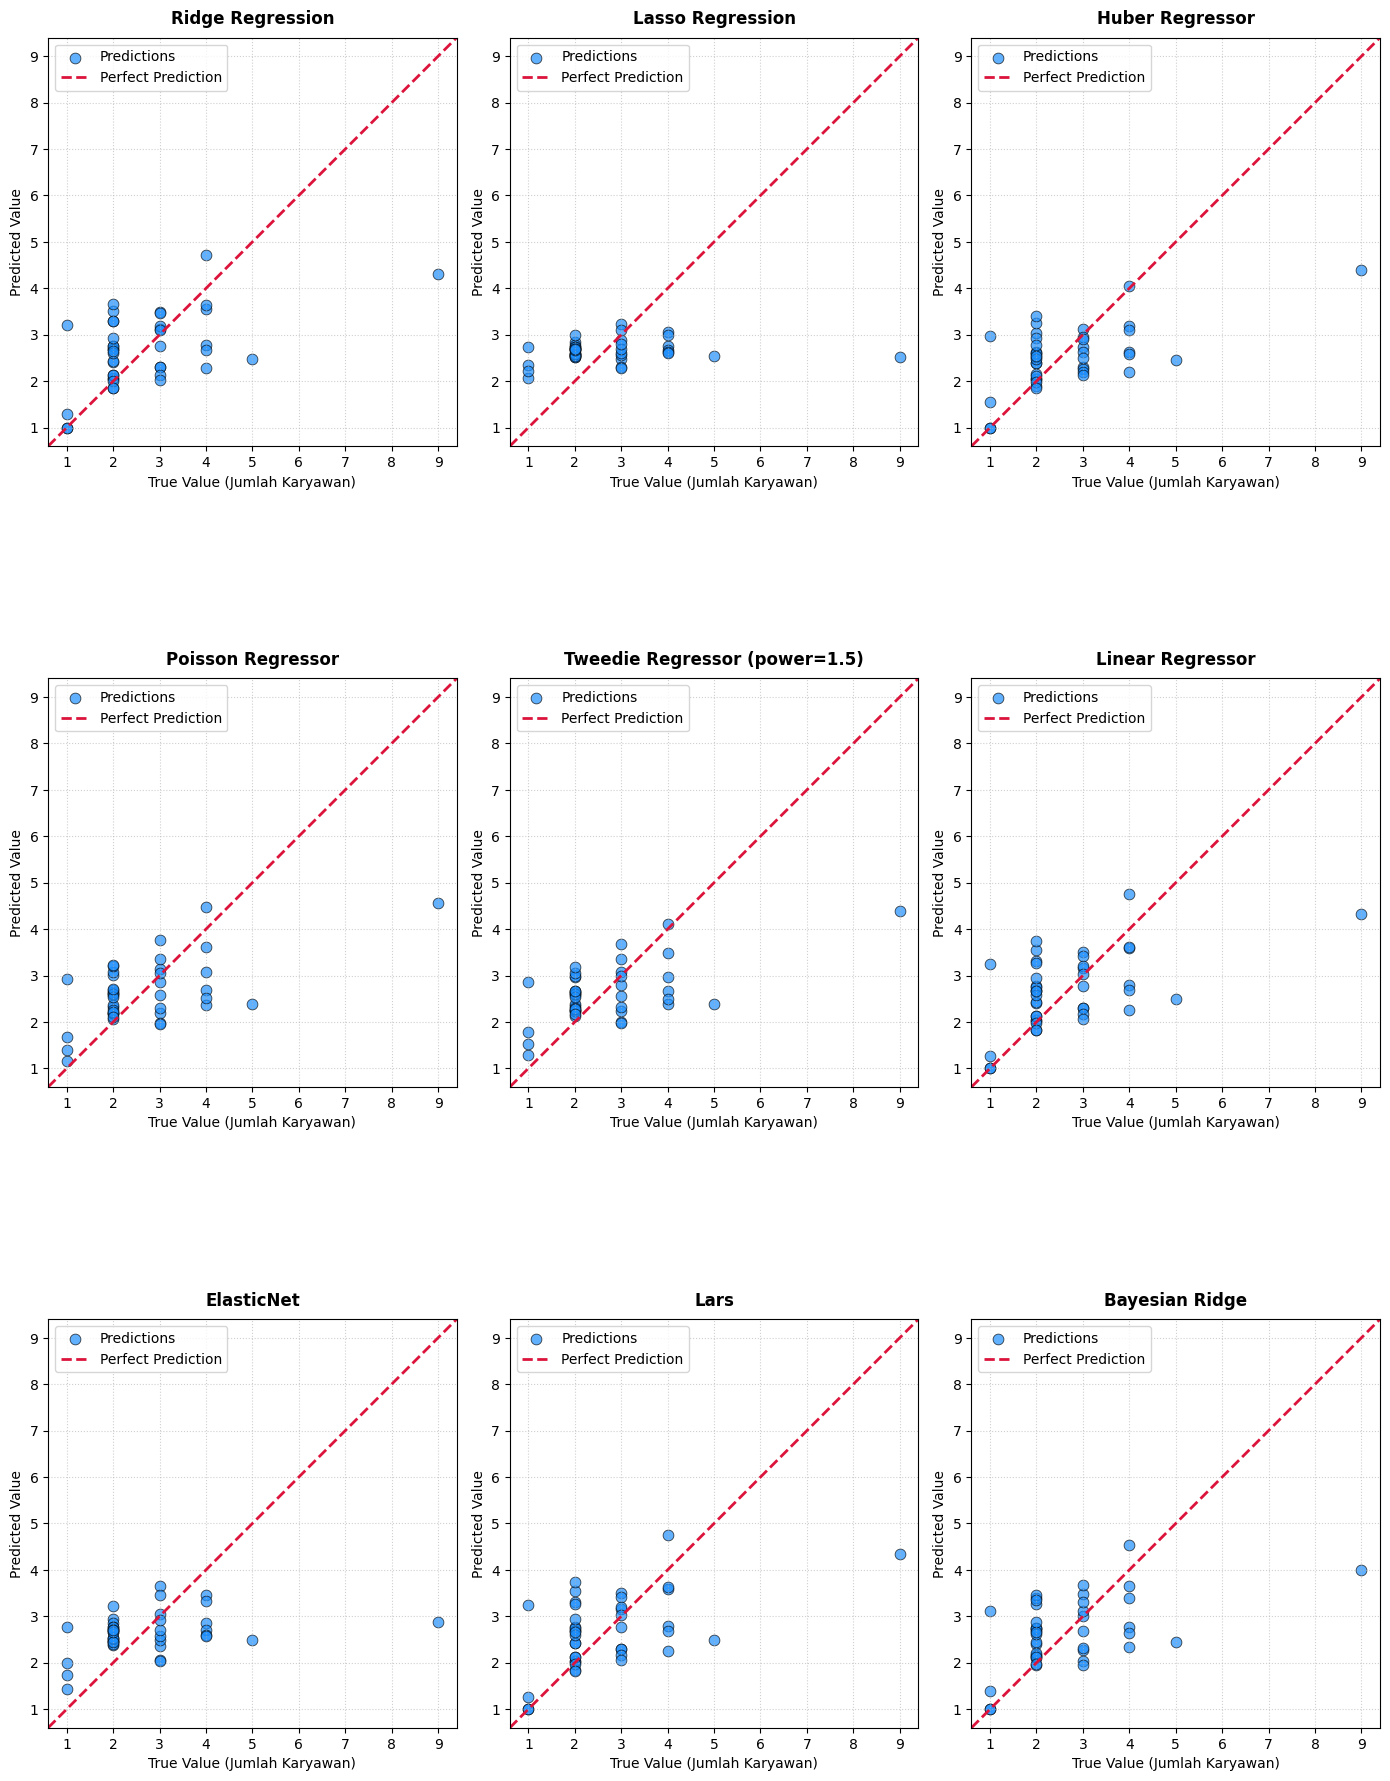

In [9]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 20))
axes = axes.flatten()

all_preds = [pred for pred in predictions_dict.values()]
min_val = min(y.min(), min([p.min() for p in all_preds]))
max_val = max(y.max(), max([p.max() for p in all_preds]))

margin = (max_val - min_val) * 0.05
lims = [min_val - margin, max_val + margin]

for idx, (name, y_pred) in enumerate(predictions_dict.items()):
    ax = axes[idx]

    sns.scatterplot(
        x=y, 
        y=y_pred, 
        ax=ax, 
        color='dodgerblue', 
        edgecolor='black', 
        alpha=0.7, 
        s=60,
        label='Predictions'
    )
    
    ax.plot(lims, lims, '--', color='crimson', linewidth=2, label='Perfect Prediction')
    
    ax.set_title(f'{name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('True Value (Jumlah Karyawan)', fontsize=10)
    ax.set_ylabel('Predicted Value', fontsize=10)
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

# fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [12]:
import optuna

# Suppress Optuna's verbose line-by-line logging for clean output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Assuming X and y are already defined from your script
loo = LeaveOneOut()

def objective(trial, model_name):
    """Optuna objective function to minimize LOO RMSE on floored predictions."""
    
    # 1. Define tight, reasonable search spaces for 42 rows
    if model_name == "Huber Regressor":
        epsilon = trial.suggest_float("epsilon", 1.1, 2.0)
        alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
        model = HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=1000)
        
    elif model_name == "Poisson Regressor":
        alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
        model = PoissonRegressor(alpha=alpha, max_iter=1000)
        
    elif model_name == "Tweedie Regressor":
        power = trial.suggest_float("power", 1.0, 1.99) # 1=Poisson, approaching 2=Gamma
        alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
        model = TweedieRegressor(power=power, alpha=alpha, max_iter=1000)
        
    elif model_name == "Ridge Regression":
        alpha = trial.suggest_float("alpha", 0.01, 100.0, log=True)
        model = Ridge(alpha=alpha)
        
    elif model_name == "Bayesian Ridge":
        alpha_1 = trial.suggest_float("alpha_1", 1e-7, 1e-3, log=True)
        alpha_2 = trial.suggest_float("alpha_2", 1e-7, 1e-3, log=True)
        lambda_1 = trial.suggest_float("lambda_1", 1e-7, 1e-3, log=True)
        lambda_2 = trial.suggest_float("lambda_2", 1e-7, 1e-3, log=True)
        model = BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2, lambda_1=lambda_1, lambda_2=lambda_2)

    # 2. Build Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=3)),
        ('regressor', model)
    ])

    # 3. Predict via LOOCV
    y_pred_raw = cross_val_predict(pipeline, X, y, cv=loo)
    
    # 4. Apply Business Logic Floor
    y_pred_final = np.maximum(1, y_pred_raw)
    
    # 5. Return RMSE as the metric to minimize
    rmse = np.sqrt(mean_squared_error(y, y_pred_final))
    return rmse

# --- Run the Optimization Flow ---
top_5_models = [
    "Huber Regressor", 
    "Poisson Regressor", 
    "Tweedie Regressor", 
    "Ridge Regression", 
    "Bayesian Ridge"
]

tuned_results = []

print("=== OPTUNA HYPERPARAMETER TUNING ===\n")

for name in top_5_models:
    # Use TPESampler with a fixed seed for reproducible results
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=19))
    
    # Pass the model name into the objective function via lambda
    study.optimize(lambda trial: objective(trial, name), n_trials=50)
    
    best_rmse = study.best_value
    best_params = study.best_params
    
    tuned_results.append({
        'Model': name,
        'Tuned LOO RMSE': round(best_rmse, 3),
        'Best Parameters': best_params
    })
    
    print(f"✔ {name} tuned. Best RMSE: {best_rmse:.3f}")

# Display Final Comparison
tuned_df = pd.DataFrame(tuned_results).sort_values(by='Tuned LOO RMSE')
print("\n=== FINAL TUNED SUMMARY ===")
print(tuned_df.to_string(index=False))

=== OPTUNA HYPERPARAMETER TUNING ===

✔ Huber Regressor tuned. Best RMSE: 1.070
✔ Poisson Regressor tuned. Best RMSE: 1.061
✔ Tweedie Regressor tuned. Best RMSE: 1.017
✔ Ridge Regression tuned. Best RMSE: 1.158
✔ Bayesian Ridge tuned. Best RMSE: 1.180

=== FINAL TUNED SUMMARY ===
            Model  Tuned LOO RMSE                                                                                                                               Best Parameters
Tweedie Regressor           1.017                                                                                   {'power': 1.9853708250816213, 'alpha': 0.02219099291939134}
Poisson Regressor           1.061                                                                                                                {'alpha': 0.03348172643224502}
  Huber Regressor           1.070                                                                               {'epsilon': 1.1019591171426675, 'alpha': 0.0011442932704514408}
 Ridge Regressi

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut, RepeatedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from sklearn.linear_model import (
    HuberRegressor, 
    PoissonRegressor, 
    TweedieRegressor, 
    Ridge, 
    BayesianRidge
)

features = ['PDRB', 'Gerai Density', 'KK Density', 'revenue_cb']
target = 'Jumlah Karyawan'

X = temp_df[features]
y = temp_df[target]

models = {
    "Ridge Regression": Ridge(alpha=1.5935612732377993),
    "Huber Regressor": HuberRegressor(epsilon=1.1019591171426675, alpha=0.0011442932704514408),
    "Poisson Regressor": PoissonRegressor(alpha=0.03348172643224502),
    "Tweedie Regressor": TweedieRegressor(power=1.9853708250816213, alpha=0.02219099291939134),
    "Bayesian Ridge": BayesianRidge(alpha_1=0.00042260193345439965, alpha_2=1.3967394907956646e-05, lambda_1=1.3656195116319212e-05, lambda_2=0.0009793066951392965)
}

loo = LeaveOneOut()
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=19)

results_hp = []
predictions_dict_hp = {}

all_detailed_predictions = {}

print("=== DUAL-STRATEGY MODEL BENCHMARKING ===\n")

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=3)),
        ('regressor', model)
    ])

    y_pred_raw_loo = cross_val_predict(pipeline, X, y, cv=loo)

    y_pred_final_loo = np.maximum(1, y_pred_raw_loo)
    predictions_dict_hp[name] =  y_pred_final_loo

    y_pred_rounded = np.maximum(1, np.round(y_pred_raw_loo)).astype(int)
    
    all_detailed_predictions[name] = {
        "result": y_pred_raw_loo.tolist(),
        "round_result": y_pred_rounded.tolist()
    }

    # Metrics calculation
    mae_loo = mean_absolute_error(y, y_pred_final_loo)
    rmse_loo = np.sqrt(mean_squared_error(y, y_pred_final_loo))
    r2_loo = r2_score(y, y_pred_final_loo)
    
    scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}
    cv_results = cross_validate(pipeline, X, y, cv=rkf, scoring=scoring)
    
    mae_rkf = -cv_results['test_mae'].mean()
    rmse_rkf = -cv_results['test_rmse'].mean()

    results_hp.append({
        'Model': name,
        'LOO RMSE': round(rmse_loo, 3),
        'RKF RMSE': round(rmse_rkf, 3),
        'RMSE Diff': round(abs(rmse_loo - rmse_rkf), 3),
        'LOO MAE': round(mae_loo, 3),
        'RKF MAE': round(mae_rkf, 3),
        'LOO R2': round(r2_loo, 3)
    })

results_df_hp = pd.DataFrame(results_hp).sort_values(by='LOO RMSE')
print(results_df_hp.to_string(index=False))

=== DUAL-STRATEGY MODEL BENCHMARKING ===

            Model  LOO RMSE  RKF RMSE  RMSE Diff  LOO MAE  RKF MAE  LOO R2
Tweedie Regressor     1.042     1.013      0.029    0.741    0.774   0.410
Poisson Regressor     1.086     1.053      0.033    0.758    0.796   0.359
  Huber Regressor     1.115     1.078      0.037    0.736    0.803   0.324
 Ridge Regression     1.180     1.152      0.028    0.783    0.871   0.244
   Bayesian Ridge     1.196     1.149      0.047    0.794    0.864   0.222


In [14]:
round_results_dict = {
    model_name: details["round_result"]
    for model_name, details in all_detailed_predictions.items()
}

rounded_predictions_df = pd.DataFrame(round_results_dict)
rounded_predictions_df["Jumlah Karyawan Saat ini"] = y.reset_index(
    drop=True
).astype(int)
rounded_predictions_df['WOK'] = temp_df['WOK'].values
res_df = rounded_predictions_df[['WOK', 'Jumlah Karyawan Saat ini'] + [col for col in rounded_predictions_df.columns if col != 'WOK' and  col != 'Jumlah Karyawan Saat ini']]
res_df['selisih'] = abs(res_df['Jumlah Karyawan Saat ini'] - res_df['Tweedie Regressor'])

In [15]:
res_df.sort_values(by='selisih', ascending=True)

,WOK,Jumlah Karyawan Saat ini,Ridge Regression,Huber Regressor,Poisson Regressor,Tweedie Regressor,Bayesian Ridge,selisih
1,BANGKALAN SAMPANG,2,2,2,2,2,2,0
2,PAMEKASAN SUMENEP,2,2,2,2,2,2,0
3,SIDOARJO PASURUAN 1,4,4,4,5,4,4,0
4,SIDOARJO PASURUAN 2,3,3,3,3,3,3,0
6,MALANG SELATAN,3,4,3,3,3,4,0
13,KOTA PROBOLINGGO,2,2,2,2,2,2,0
12,TUBAN BOJONEGORO,2,3,3,2,2,3,0
8,TULUNGAGUNG,2,2,2,2,2,2,0
24,YOGYA 2,3,3,3,3,3,3,0
26,KEBUMEN,2,2,2,2,2,2,0


In [16]:
res_df.to_csv("/home/al/kp/predictions.csv", index=False)

In [17]:
df['Prediksi'] = res_df['Tweedie Regressor']

In [18]:
df

,WOK,Luas WOK,Total Kecamatan,Total Penduduk,Jumlah Kepala Keluarga,Jumlah Gerai,PDRB,Jumlah CB,Revenue,UMR,Jumlah Karyawan,Gerai Density,KK Density,Penduduk Density,revenue_cb,Prediksi
0,SURABAYA,335.54,31.0,3010364,904222,5,2.203099e+07,344841,732,5288796.00,9,0.014901,2694.826250,8971.699350,84.101734,5
1,BANGKALAN SAMPANG,2488.40,32.0,2012310,522757,2,2.108646e+06,41699,71,2518550.44,2,0.000804,210.077560,808.676258,45.347379,2
2,PAMEKASAN SUMENEP,2883.16,40.0,1993162,618674,2,2.777703e+06,33568,59,2542732.79,2,0.000694,214.581917,691.311616,42.493357,2
3,SIDOARJO PASURUAN 1,686.15,18.0,2067820,534491,2,1.139342e+07,159467,327,5191541.00,4,0.002915,778.971070,3013.655906,69.361362,4
4,SIDOARJO PASURUAN 2,1513.41,28.0,1825010,498874,2,9.466564e+06,62276,126,5000624.69,3,0.001322,329.635723,1205.892653,53.389319,3
5,JOMBANG MOJOKERTO,1866.29,42.0,2587240,798869,2,5.511918e+06,56559,128,4117495.91,2,0.001072,428.051910,1386.301164,53.095959,3
6,MALANG SELATAN,110.06,5.0,849910,251425,2,9.560133e+06,79590,184,3736101.00,3,0.018172,2284.435762,7722.242413,58.848692,3
7,MALANG UTARA,3401.20,36.0,2885830,782347,3,4.527849e+06,74687,171,3784471.08,2,0.000882,230.020875,848.474068,57.694922,3
8,TULUNGAGUNG,2687.33,44.0,2458140,788500,2,3.561969e+06,32659,72,2593368.26,2,0.000744,293.413909,914.714605,44.451136,2
9,KEDIRI,2684.51,49.0,3035389,1013558,2,6.925423e+06,48898,110,2979821.58,2,0.000745,377.557916,1130.705045,50.753398,3


In [29]:
p_df = df.copy()

In [33]:
p_df['rpe'] = p_df['Revenue'] / p_df['Prediksi']
p_df['area_employee'] = p_df['Luas WOK'] / p_df['Prediksi']
p_df['cb_employee'] = p_df['Jumlah CB'] / p_df['Prediksi']

Text(0, 0.5, 'Customer Base per Karyawan (CB / Karyawan)')

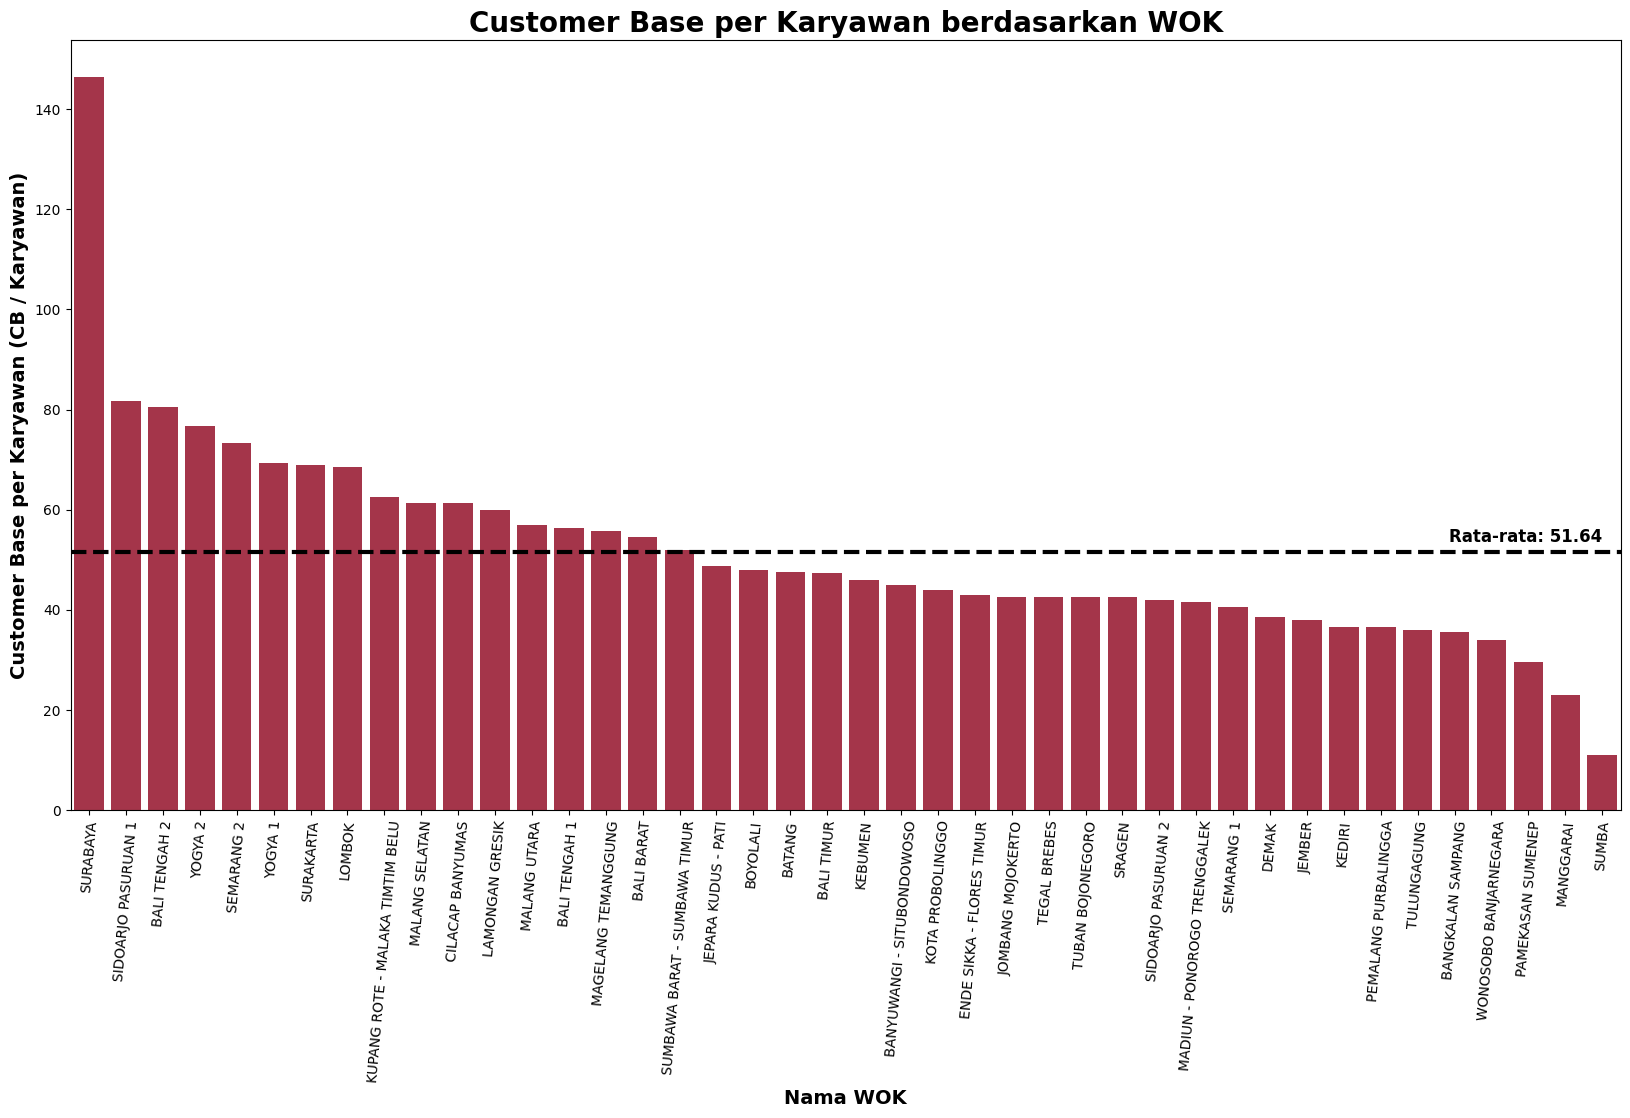

In [31]:
plt.figure(figsize=(20, 10))
sns.barplot(x='WOK', y='rpe', data=p_df.sort_values('rpe', ascending=False), color='#b7223f')
rata_rata = p_df['rpe'].mean()
plt.axhline(rata_rata, color='black', linestyle='dashed', linewidth=3)
plt.text(len(p_df) - 1, rata_rata + 2, f'Rata-rata: {rata_rata:.2f}', 
         color='black', ha='right', fontweight='bold', fontsize=12)
plt.xticks(rotation=85)

plt.title('Customer Base per Karyawan berdasarkan WOK', fontsize=20, fontweight='bold')
plt.xlabel('Nama WOK', fontsize=14, fontweight='bold')
plt.ylabel('Customer Base per Karyawan (CB / Karyawan)', fontsize=14, fontweight='bold')

# plt.savefig('/home/al/kp/assets/rpe_p.png', dpi=600, bbox_inches='tight')

Text(0, 0.5, 'Customer Base per Karyawan (CB / Karyawan)')

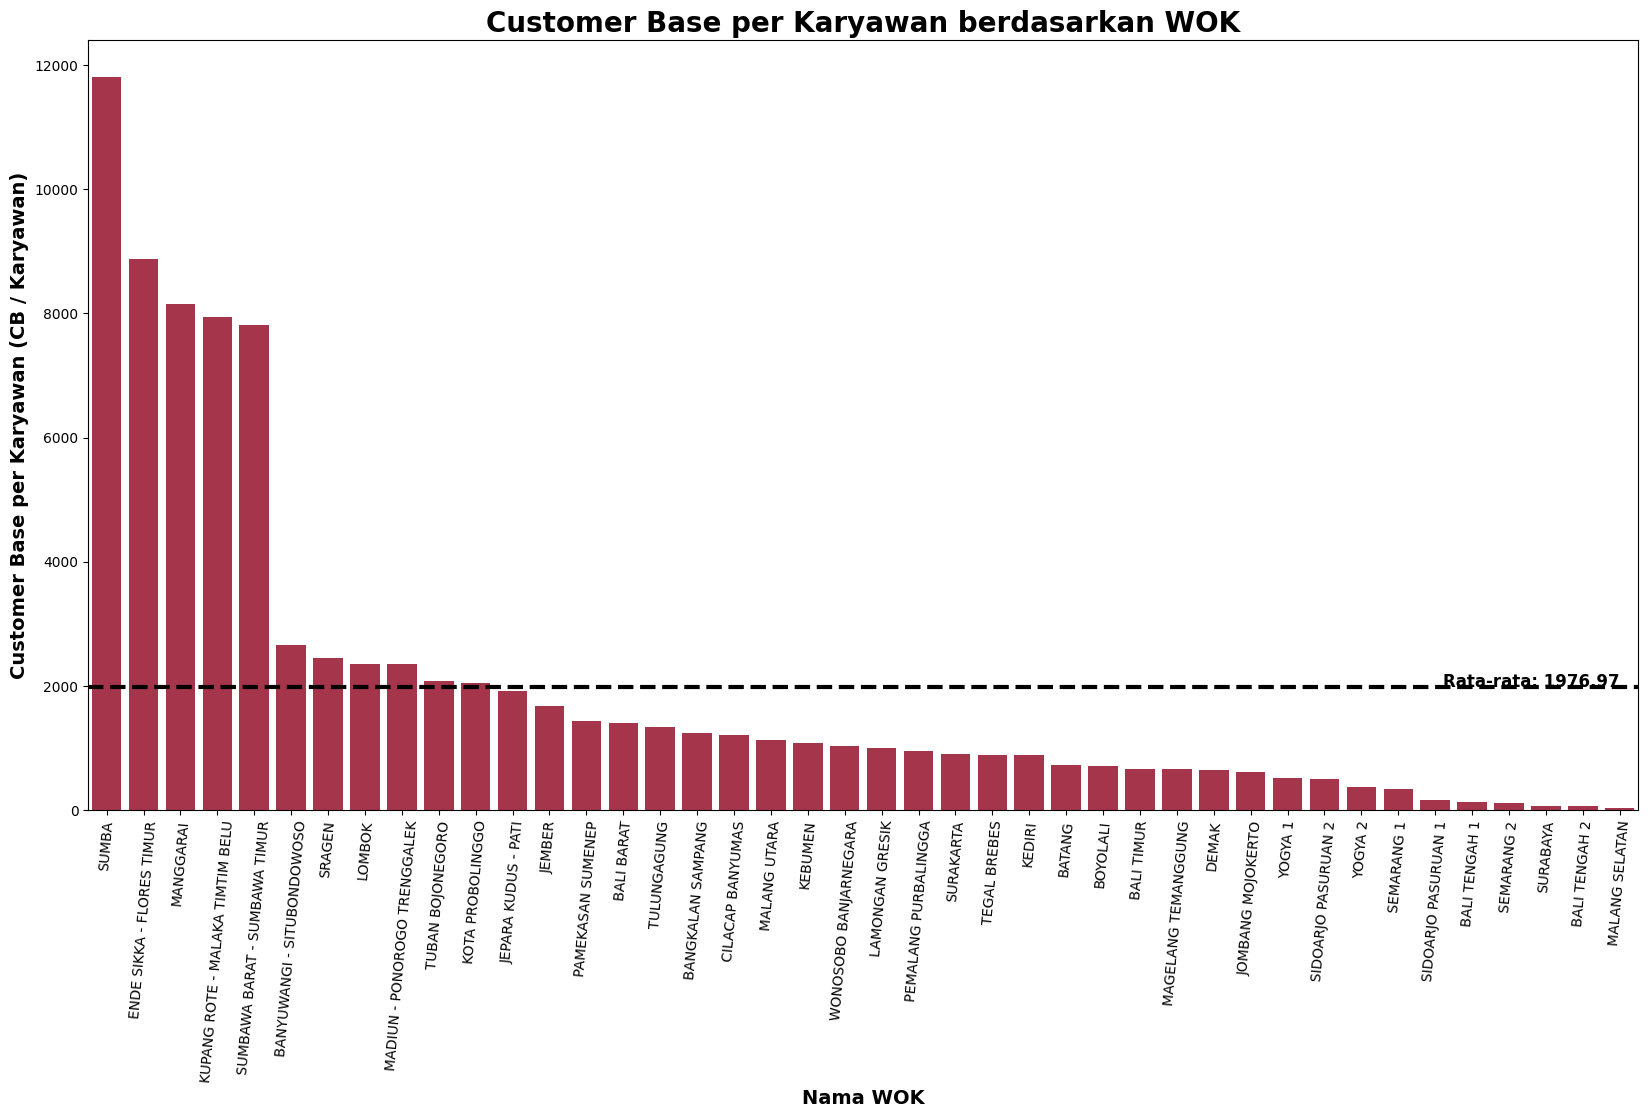

In [34]:
plt.figure(figsize=(20, 10))
sns.barplot(x='WOK', y='area_employee', data=p_df.sort_values('area_employee', ascending=False), color='#b7223f')
rata_rata = p_df['area_employee'].mean()
plt.axhline(rata_rata, color='black', linestyle='dashed', linewidth=3)
plt.text(len(p_df) - 1, rata_rata + 2, f'Rata-rata: {rata_rata:.2f}', 
         color='black', ha='right', fontweight='bold', fontsize=12)
plt.xticks(rotation=85)

plt.title('Customer Base per Karyawan berdasarkan WOK', fontsize=20, fontweight='bold')
plt.xlabel('Nama WOK', fontsize=14, fontweight='bold')
plt.ylabel('Customer Base per Karyawan (CB / Karyawan)', fontsize=14, fontweight='bold')

# plt.savefig('/home/al/kp/assets/rpe_p.png', dpi=600, bbox_inches='tight')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection     import LeaveOneOut, RepeatedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Models
from sklearn.linear_model import (
    HuberRegressor, 
    PoissonRegressor, 
    TweedieRegressor, 
    Ridge, 
    BayesianRidge
)

models = {
    "Ridge Regression": Ridge(alpha=12.924772470265477),
    "Huber Regressor": HuberRegressor(epsilon=1.6201206430933452, alpha=1.1012752332160378),
    "Poisson Regressor": PoissonRegressor(alpha=0.14379636772470392),
    "Tweedie Regressor": TweedieRegressor(power=1.9893638810538483, alpha=0.02717722369886707),
    "Bayesian Ridge": BayesianRidge(alpha_1=0.0008787526419460118, alpha_2=1.970646739946418e-06, lambda_1=0.0005292031734336532, lambda_2=0.0009940412249622665)
}

loo = LeaveOneOut()
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=19)

results_hp = []
predictions_dict_hp = {}

print("=== DUAL-STRATEGY MODEL BENCHMARKING ===\n")

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    y_pred_raw_loo = cross_val_predict(pipeline, X, y, cv=loo)
    
    y_pred_final_loo = np.maximum(1, y_pred_raw_loo)
    predictions_dict_hp[name] = y_pred_final_loo

    mae_loo = mean_absolute_error(y, y_pred_final_loo)
    rmse_loo = np.sqrt(mean_squared_error(y, y_pred_final_loo))
    r2_loo = r2_score(y, y_pred_final_loo)
    
    scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}
    cv_results = cross_validate(pipeline, X, y, cv=rkf, scoring=scoring)
    
    mae_rkf = -cv_results['test_mae'].mean()
    rmse_rkf = -cv_results['test_rmse'].mean()

    results_hp.append({
        'Model': name,
        'LOO RMSE': round(rmse_loo, 3),
        'RKF RMSE': round(rmse_rkf, 3),
        'RMSE Diff': round(abs(rmse_loo - rmse_rkf), 3),
        'LOO MAE': round(mae_loo, 3),
        'RKF MAE': round(mae_rkf, 3),
        'LOO R2': round(r2_loo, 3)
    })

results_df_hp = pd.DataFrame(results_hp).sort_values(by='LOO RMSE')
print(results_df_hp.to_string(index=False))

=== DUAL-STRATEGY MODEL BENCHMARKING ===

            Model  LOO RMSE  RKF RMSE  RMSE Diff  LOO MAE  RKF MAE  LOO R2
Tweedie Regressor     1.096     1.043      0.053    0.741    0.782   0.347
Poisson Regressor     1.131     1.079      0.052    0.756    0.801   0.305
  Huber Regressor     1.164     1.114      0.050    0.754    0.827   0.264
 Ridge Regression     1.201     1.154      0.046    0.789    0.863   0.217
   Bayesian Ridge     1.211     1.169      0.042    0.795    0.873   0.203


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut, RepeatedKFold, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Models
from sklearn.linear_model import (
    HuberRegressor, 
    PoissonRegressor, 
    TweedieRegressor, 
    Ridge, 
    BayesianRidge
)

features = ['PDRB', 'Gerai Density', 'KK Density', 'revenue_cb']
target = 'Jumlah Karyawan'

X = temp_df[features]
y = temp_df[target]

models = {
    "Ridge Regression": Ridge(alpha=1.0846272290518773),
    "Huber Regressor": HuberRegressor(epsilon=1.201390888652998, alpha=0.006750606462785486),
    "Poisson Regressor": PoissonRegressor(alpha=0.010577810127253381),
    "Tweedie Regressor": TweedieRegressor(power=1.9895068062445553, alpha=0.003765770720629282),
    "Bayesian Ridge": BayesianRidge(alpha_1=0.0005195006031578794, alpha_2=2.7313348931473034e-05, lambda_1=5.031596631305802e-05, lambda_2=0.0009988094779359144)
}

loo = LeaveOneOut()
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=19)

results_hp = []
predictions_dict_hp = {}

print("=== DUAL-STRATEGY MODEL BENCHMARKING ===\n")

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    y_pred_raw_loo = cross_val_predict(pipeline, X, y, cv=loo)
    
    y_pred_final_loo = np.maximum(1, y_pred_raw_loo)
    predictions_dict_hp[name] = y_pred_final_loo

    mae_loo = mean_absolute_error(y, y_pred_final_loo)
    rmse_loo = np.sqrt(mean_squared_error(y, y_pred_final_loo))
    r2_loo = r2_score(y, y_pred_final_loo)
    
    scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}
    cv_results = cross_validate(pipeline, X, y, cv=rkf, scoring=scoring)
    
    mae_rkf = -cv_results['test_mae'].mean()
    rmse_rkf = -cv_results['test_rmse'].mean()

    results_hp.append({
        'Model': name,
        'LOO RMSE': round(rmse_loo, 3),
        'RKF RMSE': round(rmse_rkf, 3),
        'RMSE Diff': round(abs(rmse_loo - rmse_rkf), 3),
        'LOO MAE': round(mae_loo, 3),
        'RKF MAE': round(mae_rkf, 3),
        'LOO R2': round(r2_loo, 3)
    })

results_df_hp = pd.DataFrame(results_hp).sort_values(by='LOO RMSE')
print(results_df_hp.to_string(index=False))

=== DUAL-STRATEGY MODEL BENCHMARKING ===

            Model  LOO RMSE  RKF RMSE  RMSE Diff  LOO MAE  RKF MAE  LOO R2
Tweedie Regressor     0.998     0.984      0.014    0.715    0.746   0.459
Poisson Regressor     1.053     1.024      0.030    0.735    0.769   0.397
  Huber Regressor     1.092     1.063      0.029    0.739    0.798   0.352
 Ridge Regression     1.153     1.132      0.022    0.755    0.843   0.278
   Bayesian Ridge     1.193     1.149      0.043    0.766    0.854   0.228


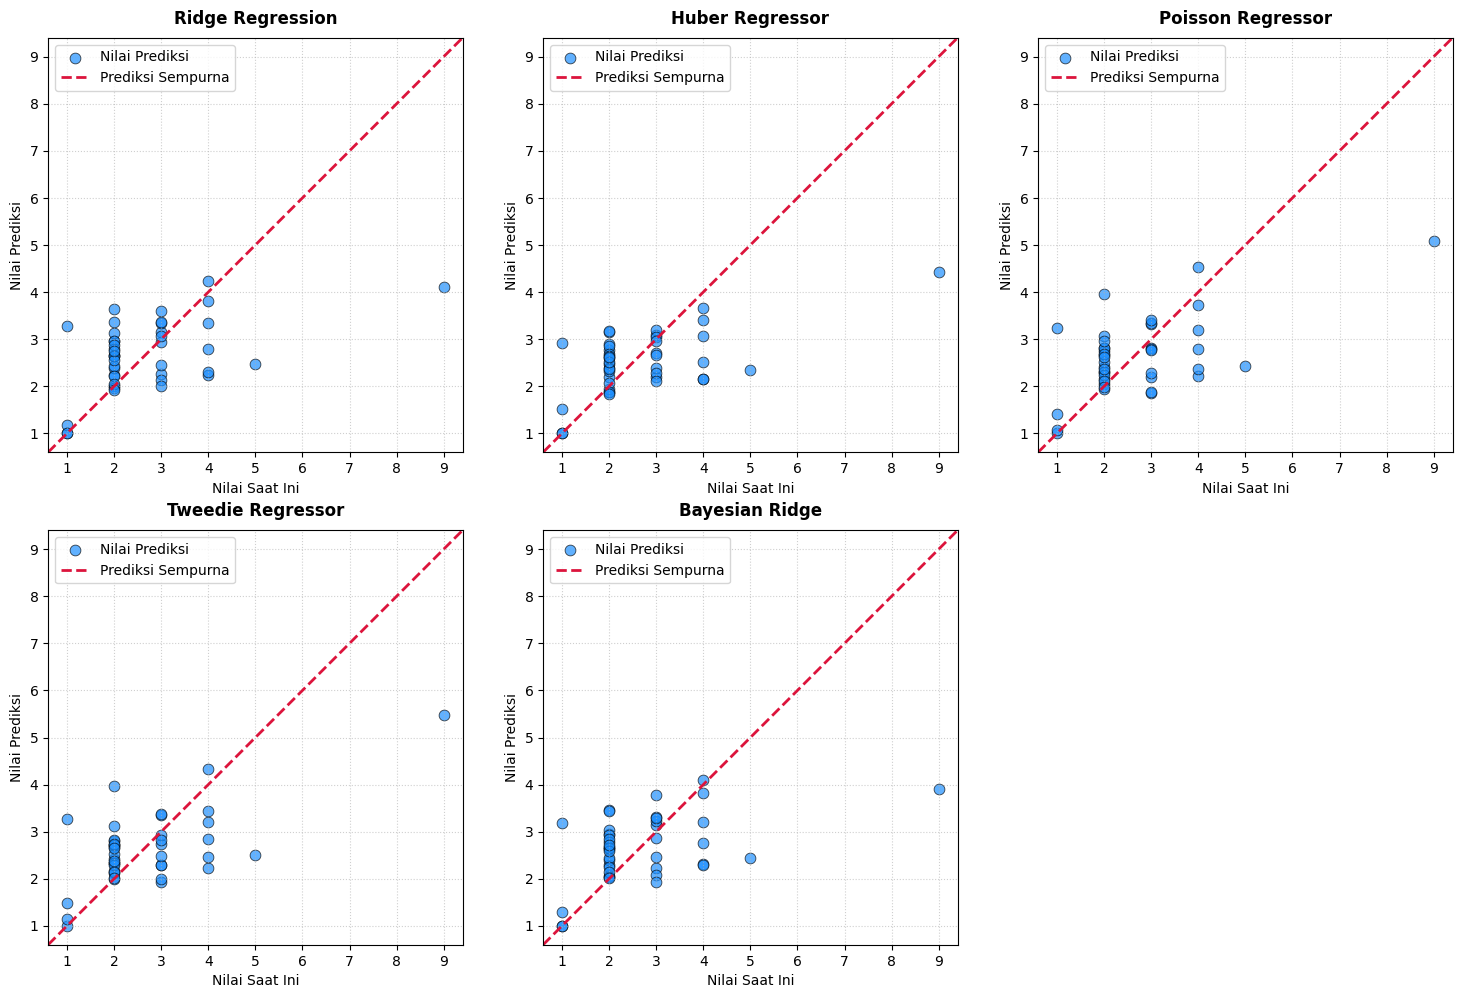

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

all_preds = [pred for pred in predictions_dict_hp.values()]
min_val = min(y.min(), min([p.min() for p in all_preds]))
max_val = max(y.max(), max([p.max() for p in all_preds]))

margin = (max_val - min_val) * 0.05
lims = [min_val - margin, max_val + margin]

for idx, (name, y_pred) in enumerate(predictions_dict_hp.items()):
    ax = axes[idx]

    sns.scatterplot(
        x=y, 
        y=y_pred, 
        ax=ax, 
        color='dodgerblue', 
        edgecolor='black', 
        alpha=0.7, 
        s=60,
        label='Nilai Prediksi'
    )
    
    ax.plot(lims, lims, '--', color='crimson', linewidth=2, label='Prediksi Sempurna')
    
    ax.set_title(f'{name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Nilai Saat Ini', fontsize=10)
    ax.set_ylabel('Nilai Prediksi', fontsize=10)
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 10))
sns.barplot(x='WOK', y='cb_per_employee', data=df.sort_values('cb_per_employee', ascending=False), color='#b7223f')
rata_rata = df['cb_per_employee'].mean()
plt.axhline(rata_rata, color='black', linestyle='dashed', linewidth=3)
plt.text(len(df) - 1, rata_rata + 1200, f'Rata-rata: {rata_rata:.2f}', 
         color='black', ha='right', fontweight='bold', fontsize=12)
plt.xticks(rotation=85)

plt.title('Customer Base per Karyawan berdasarkan WOK', fontsize=20, fontweight='bold')
plt.xlabel('Nama WOK', fontsize=14, fontweight='bold')
plt.ylabel('Customer Base per Karyawan (CB / Karyawan)', fontsize=14, fontweight='bold')

plt.savefig('/home/al/kp/assets/cb_per_employee.png', dpi=600, bbox_inches='tight')